# Dissertation Title : Evaluating a Fake News Classification Prototype Using Machine Learning and Deep Learning Models with Hyperparameter Optimization

# Step 1 : Importing Libraries

In [1]:
# I imported the pandas library to load, organise, and manipulate the dataset efficiently.
import pandas as pd

# I imported the NumPy library to perform numerical computations and support data processing tasks.
import numpy as np

# Step 2 : Loading the Dataset 

In [2]:
# I loaded the Fake News dataset from the CSV file into a DataFrame for further analysis.
df = pd.read_csv("FakeNews_15000.csv")

# I displayed the shape of the dataset to determine the total number of records and features.
print("Shape of dataset:", df.shape)

# I displayed the names of all columns to understand the dataset structure.
print("\nColumn Names:")
print(df.columns)

# I displayed the first five rows to inspect the dataset and verify that it had been loaded correctly.
print("\nFirst 5 Rows:")
print(df.head())

# I displayed the data types of all columns to identify numerical and textual features.
print("\nData Types:")
print(df.dtypes)

Shape of dataset: (15000, 4)

Column Names:
Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

First 5 Rows:
   Unnamed: 0                                              title  \
0       61370  ARNOLD SCHWARZENEGGER Sends A Message To Liber...   
1        2189  WOW! “We Mexicans Need To Kill Donald Trump Be...   
2       60609  Jimmy Carter recovers from dehydration scare i...   
3       51565  2 Friars’ Mission: Reviving a Brooklyn Church ...   
4       39431  Boy With Autism Makes His First Friend Ever An...   

                                                text  label  
0                                                         1  
1  And now a message of peace and unity from one ...      1  
2  WINNIPEG, Manitoba (Reuters) - Former U.S. Pre...      0  
3  The two Franciscan friars, complete with   rob...      0  
4  Approximately 1 in 68 children has an autism s...      1  

Data Types:
Unnamed: 0     int64
title         object
text          object
label          int64

# Step 3 : Structure and Overview of the Dataset 

In [3]:
# I calculated the total number of observations (rows) present in the dataset.
num_observations = df.shape[0]

# I calculated the total number of features (columns) available in the dataset.
num_features = df.shape[1]

# I displayed the total number of observations to understand the dataset size.
print(f"\nNumber of observations (rows): {num_observations}")

# I initialized a variable to identify the target variable automatically.
target_col = None

# I examined each column to identify the target variable based on the number of unique values and its data type.
for col in df.columns:
    if df[col].nunique() <= 5 and df[col].dtype != 'object':
        target_col = col
        break

# I selected the last column as the target variable if no suitable column had been identified automatically.
if target_col is None:
    target_col = df.columns[-1]

# I displayed the detected target variable for the fake news classification task.
print(f"\nDetected Target Variable: {target_col}")

# I identified all remaining columns as independent variables by excluding the target variable.
independent_vars = [col for col in df.columns if col != target_col]

# I displayed the independent variables that would be used as input features during model training.
print("\nIndependent Variables:")
print(independent_vars)

# I displayed detailed information about each column, including data types and non-null values.
print("\nColumn Information:")
print(df.info())

# I displayed the statistical summary of the numerical features to understand their distribution and characteristics.
print("\nStatistical Summary:\n")
print(df.describe())


Number of observations (rows): 15000

Detected Target Variable: label

Independent Variables:
['Unnamed: 0', 'title', 'text']

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  15000 non-null  int64 
 1   title       14889 non-null  object
 2   text        14993 non-null  object
 3   label       15000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 468.9+ KB
None

Statistical Summary:

         Unnamed: 0         label
count  15000.000000  15000.000000
mean   36029.049000      0.509267
std    20692.703553      0.499931
min        4.000000      0.000000
25%    18055.250000      0.000000
50%    36153.000000      1.000000
75%    53668.250000      1.000000
max    72124.000000      1.000000


# Step 4 : Data Pre-Processing

In [4]:
# I displayed the number of missing values in each column to identify incomplete records.
print("Missing Values:\n")
print(df.isnull().sum())

# I removed the unnecessary index column because it did not contribute to fake news classification.
df.drop(columns=["Unnamed: 0"], inplace=True)

# I removed records containing missing values to ensure data quality.
df.dropna(inplace=True)

# I displayed the dataset shape after removing missing values.
print("\nDataset Shape after Removing Missing Values:", df.shape)

# I checked for duplicate records in the dataset.
print("\nDuplicate Records:", df.duplicated().sum())

# I removed duplicate records to avoid redundant information during model training.
df.drop_duplicates(inplace=True)

# I displayed the dataset shape after removing duplicate records.
print("\nDataset Shape after Removing Duplicates:", df.shape)

# I converted the title column into string format to ensure consistency during text processing.
df["title"] = df["title"].astype(str)

# I converted the text column into string format to ensure consistency during text processing.
df["text"] = df["text"].astype(str)

# I combined the title and news content into a single feature to improve the amount of textual information available for classification.
df["content"] = df["title"] + " " + df["text"]

# I displayed the first five rows of the cleaned dataset to verify the preprocessing results.
print("\nFirst 5 Rows of the Preprocessed Dataset:\n")
print(df.head())

# I displayed the final dataset information after completing the preprocessing stage.
print("\nPreprocessed Dataset Information:\n")
print(df.info())

Missing Values:

Unnamed: 0      0
title         111
text            7
label           0
dtype: int64

Dataset Shape after Removing Missing Values: (14882, 3)

Duplicate Records: 382

Dataset Shape after Removing Duplicates: (14500, 3)

First 5 Rows of the Preprocessed Dataset:

                                               title  \
0  ARNOLD SCHWARZENEGGER Sends A Message To Liber...   
1  WOW! “We Mexicans Need To Kill Donald Trump Be...   
2  Jimmy Carter recovers from dehydration scare i...   
3  2 Friars’ Mission: Reviving a Brooklyn Church ...   
4  Boy With Autism Makes His First Friend Ever An...   

                                                text  label  \
0                                                         1   
1  And now a message of peace and unity from one ...      1   
2  WINNIPEG, Manitoba (Reuters) - Former U.S. Pre...      0   
3  The two Franciscan friars, complete with   rob...      0   
4  Approximately 1 in 68 children has an autism s...      1   

    

# Step 5 : Exploratory Data Analysis 

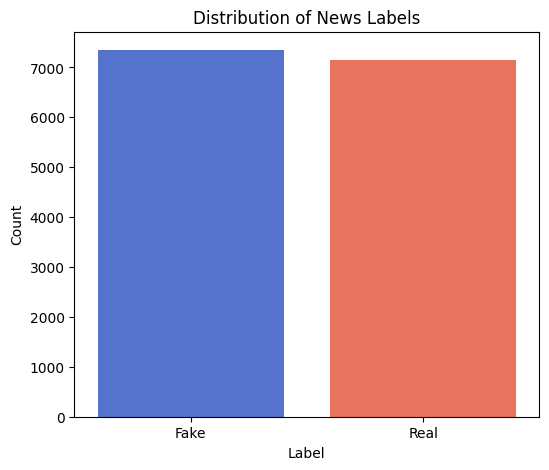

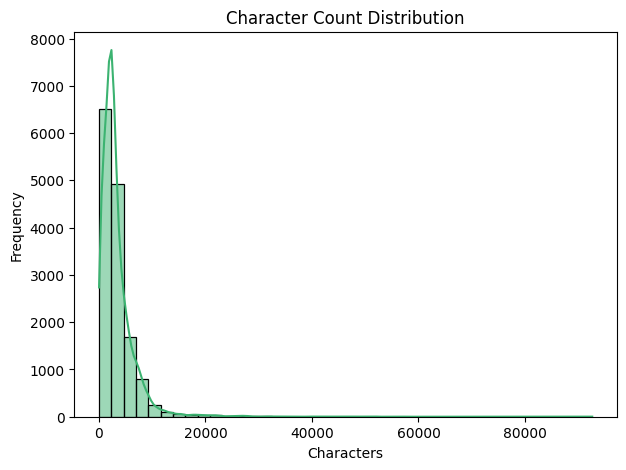

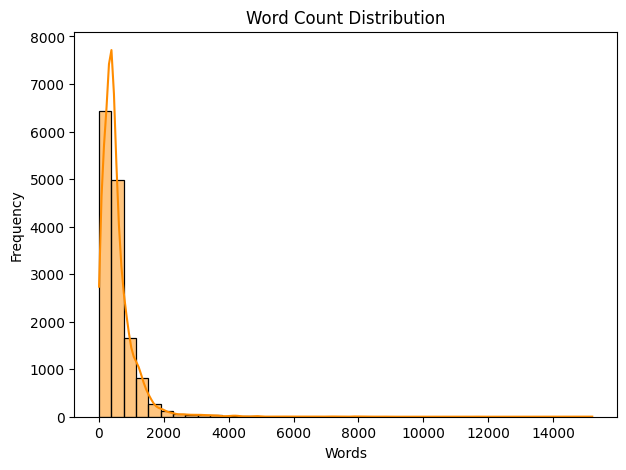

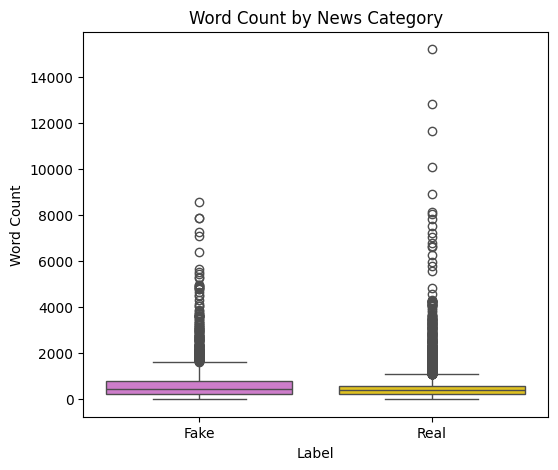

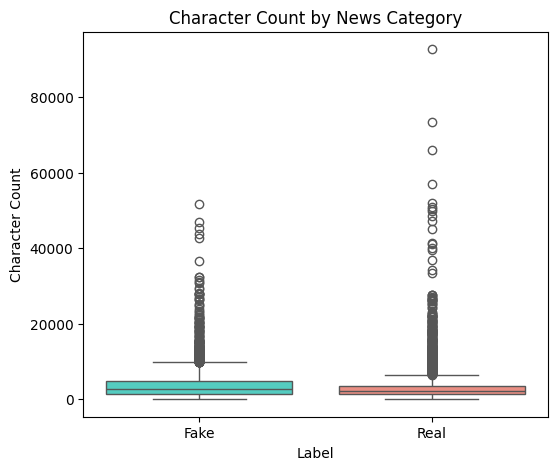

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# I calculated the character count for each news article.
df["Character_Count"] = df["content"].apply(len)

# I calculated the word count for each news article.
df["Word_Count"] = df["content"].apply(lambda x: len(x.split()))

# Target Variable Distribution
# I visualized the distribution of fake and real news articles to examine whether the dataset was balanced.

plt.figure(figsize=(6,5))
sns.countplot(x="label", hue="label", data=df,
              palette=["royalblue", "tomato"], legend=False)
plt.title("Distribution of News Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0,1],["Fake","Real"])
plt.show()


# Character Count Distribution
# I visualized the distribution of article lengths based on the number of characters.

plt.figure(figsize=(7,5))
sns.histplot(df["Character_Count"],
             bins=40,
             kde=True,
             color="mediumseagreen")

plt.title("Character Count Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()


# Word Count Distribution
# I visualized the distribution of the total number of words present in each news article.

plt.figure(figsize=(7,5))
sns.histplot(df["Word_Count"],
             bins=40,
             kde=True,
             color="darkorange")

plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


# Word Count by News Category
# I compared the word count between fake and real news articles.

plt.figure(figsize=(6,5))
sns.boxplot(
    x="label",
    y="Word_Count",
    hue="label",
    data=df,
    palette=["orchid", "gold"],
    legend=False
)

plt.title("Word Count by News Category")
plt.xlabel("Label")
plt.ylabel("Word Count")
plt.xticks([0,1],["Fake","Real"])
plt.show()


# Character Count by News Category
# I compared the character count between fake and real news articles.

plt.figure(figsize=(6,5))
sns.boxplot(
    x="label",
    y="Character_Count",
    hue="label",
    data=df,
    palette=["turquoise", "salmon"],
    legend=False
)

plt.title("Character Count by News Category")
plt.xlabel("Label")
plt.ylabel("Character Count")
plt.xticks([0,1],["Fake","Real"])
plt.show()

# Step 6 : Importing Libraries related to Natural Language Processing [NLP] Tool Kit 

In [6]:
# I imported the regular expression library to perform text cleaning.
import re

# I imported the Natural Language Toolkit library for natural language processing.
import nltk

# I imported the English stopword list from the NLTK library.
from nltk.corpus import stopwords

# I imported the WordNet Lemmatizer to convert words into their base forms.
from nltk.stem import WordNetLemmatizer

# I imported the TF-IDF vectorizer to convert text into numerical features.
from sklearn.feature_extraction.text import TfidfVectorizer

# I imported the train-test split function to divide the dataset into training and testing sets.
from sklearn.model_selection import train_test_split

# I imported the StandardScaler to standardize the numerical feature values.
from sklearn.preprocessing import StandardScaler

# I initialized the English stopword list.
stop_words = set(stopwords.words("english"))
# I downloaded the English stopword corpus required for text preprocessing.
nltk.download("stopwords")

# I downloaded the WordNet lexical database required for lemmatization.
nltk.download("wordnet")

# I downloaded additional WordNet resources required for lemmatization.
nltk.download("omw-1.4")


# I initialized the WordNet lemmatizer.
lemmatizer = WordNetLemmatizer()

# Step 7 : Text Pre-Processing

In [7]:
# I created a function to preprocess the news text.
def preprocess_text(text):

    # I converted all characters into lowercase.
    text = text.lower()

    # I removed URLs from the text.
    text = re.sub(r"http\S+|www\S+", "", text)

    # I removed HTML tags from the text.
    text = re.sub(r"<.*?>", "", text)

    # I removed numbers and punctuation marks.
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # I removed extra white spaces.
    text = re.sub(r"\s+", " ", text).strip()

    # I split the text into individual words.
    words = text.split()

    # I removed English stopwords.
    words = [word for word in words if word not in stop_words]

    # I converted each word into its root form using lemmatization.
    words = [lemmatizer.lemmatize(word) for word in words]

    # I returned the cleaned sentence.
    return " ".join(words)

# I applied the preprocessing function to the combined news content.
df["clean_content"] = df["content"].apply(preprocess_text)

# I displayed the original news article.
print("Original News Article:")
print(df["content"].iloc[0])

# I displayed the cleaned news article.
print("\nCleaned News Article:")
print(df["clean_content"].iloc[0])

Original News Article:
ARNOLD SCHWARZENEGGER Sends A Message To Liberals Whining About Trump [Video]  

Cleaned News Article:
arnold schwarzenegger sends message liberal whining trump video


# Step 8 : Feature Extraction Using TF-IDF, BoW  and Data Splitting 

# TF-IDF : Term Frequency - Inverse Document Frequency 

# BoW : Bag Of Words 

In [8]:
# I imported the Bag of Words vectorizer to convert text into numerical word frequency features.
from sklearn.feature_extraction.text import CountVectorizer

# I initialized the TF-IDF vectorizer using unigrams and bigrams.
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# I transformed the cleaned news articles into TF-IDF feature vectors.
X_tfidf = tfidf.fit_transform(df["clean_content"])

# I selected the news labels as the target variable.
y = df["label"]

# I displayed the dimensions of the TF-IDF feature matrix.
print("\nTF-IDF Feature Matrix Shape:")
print(X_tfidf.shape)

# I extracted the names of all generated TF-IDF features.
tfidf_feature_names = tfidf.get_feature_names_out()

# I displayed the first twenty TF-IDF features.
print("\nFirst Twenty TF-IDF Features:")
print(tfidf_feature_names[:20])

# I initialized the Bag of Words vectorizer using unigrams and bigrams.
bow = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# I transformed the cleaned news articles into Bag of Words feature vectors.
X_bow = bow.fit_transform(df["clean_content"])

# I displayed the dimensions of the Bag of Words feature matrix.
print("\nBag of Words Feature Matrix Shape:")
print(X_bow.shape)

# I extracted the names of all generated Bag of Words features.
bow_feature_names = bow.get_feature_names_out()

# I displayed the first twenty Bag of Words features.
print("\nFirst Twenty Bag of Words Features:")
print(bow_feature_names[:20])

# I displayed the dimensions of the target variable.
print("\nTarget Variable Shape:")
print(y.shape)

# I divided the TF-IDF feature matrix into training and testing datasets.
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# I displayed the dimensions of the TF-IDF training feature set.
print("\nTF-IDF Training Feature Shape:")
print(X_train_tfidf.shape)

# I displayed the dimensions of the TF-IDF testing feature set.
print("\nTF-IDF Testing Feature Shape:")
print(X_test_tfidf.shape)

# I divided the Bag of Words feature matrix into training and testing datasets.
X_train_bow, X_test_bow, _, _ = train_test_split(
    X_bow,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# I displayed the dimensions of the Bag of Words training feature set.
print("\nBag of Words Training Feature Shape:")
print(X_train_bow.shape)

# I displayed the dimensions of the Bag of Words testing feature set.
print("\nBag of Words Testing Feature Shape:")
print(X_test_bow.shape)

# I displayed the class distribution of the training dataset.
print("\nTraining Class Distribution:")
print(y_train.value_counts())

# I displayed the class distribution of the testing dataset.
print("\nTesting Class Distribution:")
print(y_test.value_counts())


TF-IDF Feature Matrix Shape:
(14500, 5000)

First Twenty TF-IDF Features:
['abandon' 'abandoned' 'abc' 'abc news' 'abe' 'abedin' 'ability' 'able'
 'abortion' 'abroad' 'absence' 'absolute' 'absolutely' 'abu' 'abuse'
 'academic' 'academy' 'accept' 'acceptable' 'acceptance']

Bag of Words Feature Matrix Shape:
(14500, 5000)

First Twenty Bag of Words Features:
['abandon' 'abandoned' 'abc' 'abc news' 'abe' 'abedin' 'ability' 'able'
 'abortion' 'abroad' 'absence' 'absolute' 'absolutely' 'abu' 'abuse'
 'academic' 'academy' 'accept' 'acceptable' 'acceptance']

Target Variable Shape:
(14500,)

TF-IDF Training Feature Shape:
(11600, 5000)

TF-IDF Testing Feature Shape:
(2900, 5000)

Bag of Words Training Feature Shape:
(11600, 5000)

Bag of Words Testing Feature Shape:
(2900, 5000)

Training Class Distribution:
label
0    5878
1    5722
Name: count, dtype: int64

Testing Class Distribution:
label
0    1470
1    1430
Name: count, dtype: int64


# Step 9 : Synthetic Minority Oversampling Technique (SMOTE) for Both Tecniques 

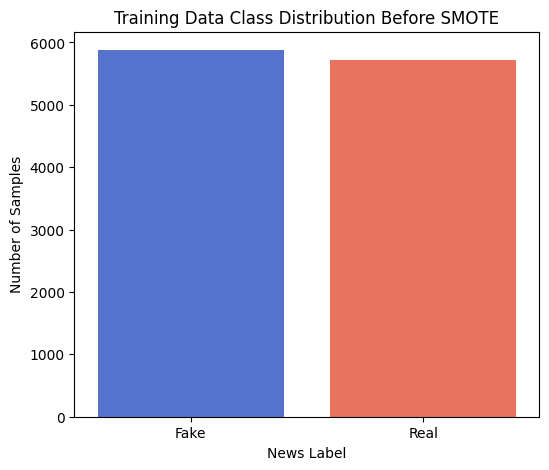


Training Class Distribution Before SMOTE:
label
0    5878
1    5722
Name: count, dtype: int64

Balanced TF-IDF Training Feature Shape:
(11756, 5000)

Balanced TF-IDF Training Class Distribution:
label
1    5878
0    5878
Name: count, dtype: int64

Balanced Bag of Words Training Feature Shape:
(11756, 5000)

Balanced Bag of Words Training Class Distribution:
label
1    5878
0    5878
Name: count, dtype: int64


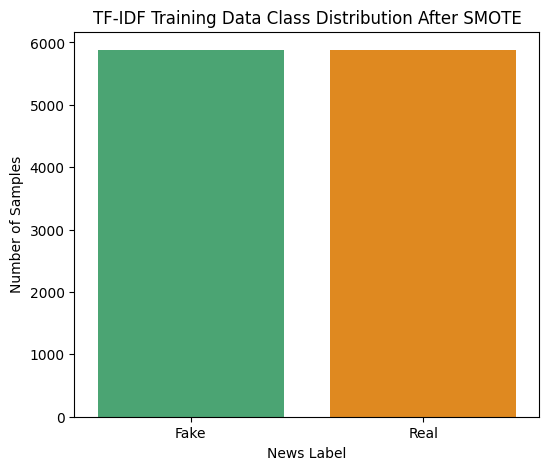

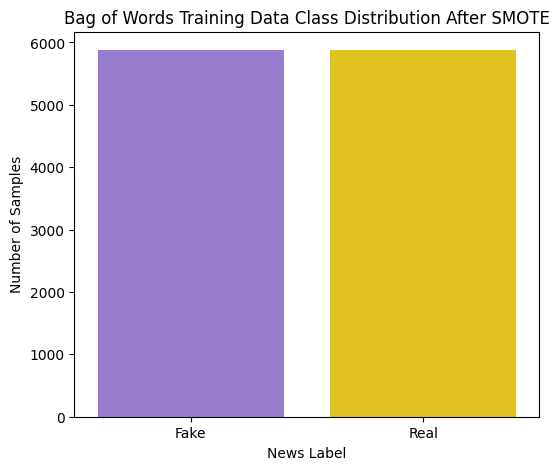


TF-IDF Training Samples After SMOTE:
11756

Bag of Words Training Samples After SMOTE:
11756


In [9]:
# I imported the SMOTE technique for balancing the training dataset.
from imblearn.over_sampling import SMOTE

# I visualized the class distribution before applying SMOTE.
plt.figure(figsize=(6,5))
sns.countplot(
    x=y_train,
    hue=y_train,
    palette=["royalblue", "tomato"],
    legend=False
)

# I added the chart title.
plt.title("Training Data Class Distribution Before SMOTE")

# I labelled the x-axis.
plt.xlabel("News Label")

# I labelled the y-axis.
plt.ylabel("Number of Samples")

# I renamed the class labels.
plt.xticks([0,1],["Fake","Real"])

# I displayed the plot.
plt.show()

# I displayed the class distribution before applying SMOTE.
print("\nTraining Class Distribution Before SMOTE:")
print(y_train.value_counts())

# I initialized the SMOTE algorithm.
smote = SMOTE(random_state=42)

# I applied SMOTE to the TF-IDF training dataset.
X_train_tfidf_smote, y_train_tfidf_smote = smote.fit_resample(
    X_train_tfidf,
    y_train
)

# I displayed the dimensions of the balanced TF-IDF training dataset.
print("\nBalanced TF-IDF Training Feature Shape:")
print(X_train_tfidf_smote.shape)

# I displayed the class distribution of the balanced TF-IDF training dataset.
print("\nBalanced TF-IDF Training Class Distribution:")
print(y_train_tfidf_smote.value_counts())

# I applied SMOTE to the Bag of Words training dataset.
X_train_bow_smote, y_train_bow_smote = smote.fit_resample(
    X_train_bow,
    y_train
)

# I displayed the dimensions of the balanced Bag of Words training dataset.
print("\nBalanced Bag of Words Training Feature Shape:")
print(X_train_bow_smote.shape)

# I displayed the class distribution of the balanced Bag of Words training dataset.
print("\nBalanced Bag of Words Training Class Distribution:")
print(y_train_bow_smote.value_counts())

# I visualized the class distribution after applying SMOTE to the TF-IDF training dataset.
plt.figure(figsize=(6,5))
sns.countplot(
    x=y_train_tfidf_smote,
    hue=y_train_tfidf_smote,
    palette=["mediumseagreen", "darkorange"],
    legend=False
)

# I added the chart title.
plt.title("TF-IDF Training Data Class Distribution After SMOTE")

# I labelled the x-axis.
plt.xlabel("News Label")

# I labelled the y-axis.
plt.ylabel("Number of Samples")

# I renamed the class labels.
plt.xticks([0,1],["Fake","Real"])

# I displayed the plot.
plt.show()

# I visualized the class distribution after applying SMOTE to the Bag of Words training dataset.
plt.figure(figsize=(6,5))
sns.countplot(
    x=y_train_bow_smote,
    hue=y_train_bow_smote,
    palette=["mediumpurple", "gold"],
    legend=False
)

# I added the chart title.
plt.title("Bag of Words Training Data Class Distribution After SMOTE")

# I labelled the x-axis.
plt.xlabel("News Label")

# I labelled the y-axis.
plt.ylabel("Number of Samples")

# I renamed the class labels.
plt.xticks([0,1],["Fake","Real"])

# I displayed the plot.
plt.show()

# I displayed the total number of TF-IDF training samples after SMOTE.
print("\nTF-IDF Training Samples After SMOTE:")
print(X_train_tfidf_smote.shape[0])

# I displayed the total number of Bag of Words training samples after SMOTE.
print("\nBag of Words Training Samples After SMOTE:")
print(X_train_bow_smote.shape[0])

# Step 10 : Model Selection & Training 

# Machine Learning Algorithms 

# Baseline Models (Before Hyper Parameter Tuning)

# Technique 1 : TF-IDF 

# Model 1 : Logistic Regression (TF-IDF)

In [10]:
# I imported the Logistic Regression classifier.
from sklearn.linear_model import LogisticRegression

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Logistic Regression classifier with default parameters.
base_lr_tfidf = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# I trained the Logistic Regression model using the SMOTE-balanced TF-IDF training dataset.
base_lr_tfidf.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I predicted the class labels for the TF-IDF testing dataset.
base_lr_tfidf_predictions = base_lr_tfidf.predict(
    X_test_tfidf
)

# I predicted the class probabilities for the TF-IDF testing dataset.
base_lr_tfidf_probabilities = base_lr_tfidf.predict_proba(
    X_test_tfidf
)[:, 1]

# I calculated the accuracy score.
base_lr_tfidf_accuracy = accuracy_score(
    y_test,
    base_lr_tfidf_predictions
)

# I calculated the precision score.
base_lr_tfidf_precision = precision_score(
    y_test,
    base_lr_tfidf_predictions
)

# I calculated the recall score.
base_lr_tfidf_recall = recall_score(
    y_test,
    base_lr_tfidf_predictions
)

# I calculated the F1-score.
base_lr_tfidf_f1_score = f1_score(
    y_test,
    base_lr_tfidf_predictions
)

# I calculated the ROC-AUC score.
base_lr_tfidf_roc_auc = roc_auc_score(
    y_test,
    base_lr_tfidf_probabilities
)

# I generated the classification report.
base_lr_tfidf_classification_report = classification_report(
    y_test,
    base_lr_tfidf_predictions
)

# I displayed the evaluation metrics.
print("\nLogistic Regression (TF-IDF) Performance")

print(f"Accuracy: {base_lr_tfidf_accuracy:.4f}")
print(f"Precision: {base_lr_tfidf_precision:.4f}")
print(f"Recall: {base_lr_tfidf_recall:.4f}")
print(f"F1-Score: {base_lr_tfidf_f1_score:.4f}")
print(f"ROC-AUC: {base_lr_tfidf_roc_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report:")
print(base_lr_tfidf_classification_report)


Logistic Regression (TF-IDF) Performance
Accuracy: 0.9221
Precision: 0.9163
Recall: 0.9266
F1-Score: 0.9214
ROC-AUC: 0.9740

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      1470
           1       0.92      0.93      0.92      1430

    accuracy                           0.92      2900
   macro avg       0.92      0.92      0.92      2900
weighted avg       0.92      0.92      0.92      2900



# Technique 2 : BoW

# Model 1 : Logistic Regression (Using BoW)

In [11]:
# I imported the Logistic Regression classifier.
from sklearn.linear_model import LogisticRegression

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Logistic Regression classifier with default parameters.
base_lr_bow = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# I trained the Logistic Regression model using the SMOTE-balanced Bag of Words training dataset.
base_lr_bow.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I predicted the class labels for the Bag of Words testing dataset.
base_lr_bow_predictions = base_lr_bow.predict(
    X_test_bow
)

# I predicted the class probabilities for the Bag of Words testing dataset.
base_lr_bow_probabilities = base_lr_bow.predict_proba(
    X_test_bow
)[:, 1]

# I calculated the accuracy score.
base_lr_bow_accuracy = accuracy_score(
    y_test,
    base_lr_bow_predictions
)

# I calculated the precision score.
base_lr_bow_precision = precision_score(
    y_test,
    base_lr_bow_predictions
)

# I calculated the recall score.
base_lr_bow_recall = recall_score(
    y_test,
    base_lr_bow_predictions
)

# I calculated the F1-score.
base_lr_bow_f1_score = f1_score(
    y_test,
    base_lr_bow_predictions
)

# I calculated the ROC-AUC score.
base_lr_bow_roc_auc = roc_auc_score(
    y_test,
    base_lr_bow_probabilities
)

# I generated the classification report.
base_lr_bow_classification_report = classification_report(
    y_test,
    base_lr_bow_predictions
)

# I displayed the evaluation metrics.
print("\nLogistic Regression (Bag of Words) Performance")

print(f"Accuracy: {base_lr_bow_accuracy:.4f}")
print(f"Precision: {base_lr_bow_precision:.4f}")
print(f"Recall: {base_lr_bow_recall:.4f}")
print(f"F1-Score: {base_lr_bow_f1_score:.4f}")
print(f"ROC-AUC: {base_lr_bow_roc_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report:")
print(base_lr_bow_classification_report)


Logistic Regression (Bag of Words) Performance
Accuracy: 0.9324
Precision: 0.9297
Recall: 0.9336
F1-Score: 0.9316
ROC-AUC: 0.9716

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      1470
           1       0.93      0.93      0.93      1430

    accuracy                           0.93      2900
   macro avg       0.93      0.93      0.93      2900
weighted avg       0.93      0.93      0.93      2900



# Model 2 : Random Forest (Using TF-IDF)

# Model 2 : Random Forest (Using TF-IDF)

In [12]:
# I imported the Random Forest classifier.
from sklearn.ensemble import RandomForestClassifier

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Random Forest classifier with default parameters.
base_rf_tfidf = RandomForestClassifier(
    random_state=42
)

# I trained the Random Forest model using the SMOTE-balanced TF-IDF training dataset.
base_rf_tfidf.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I predicted the class labels for the TF-IDF testing dataset.
base_rf_tfidf_predictions = base_rf_tfidf.predict(
    X_test_tfidf
)

# I predicted the class probabilities for the TF-IDF testing dataset.
base_rf_tfidf_probabilities = base_rf_tfidf.predict_proba(
    X_test_tfidf
)[:, 1]

# I calculated the accuracy score.
base_rf_tfidf_accuracy = accuracy_score(
    y_test,
    base_rf_tfidf_predictions
)

# I calculated the precision score.
base_rf_tfidf_precision = precision_score(
    y_test,
    base_rf_tfidf_predictions
)

# I calculated the recall score.
base_rf_tfidf_recall = recall_score(
    y_test,
    base_rf_tfidf_predictions
)

# I calculated the F1-score.
base_rf_tfidf_f1_score = f1_score(
    y_test,
    base_rf_tfidf_predictions
)

# I calculated the ROC-AUC score.
base_rf_tfidf_roc_auc = roc_auc_score(
    y_test,
    base_rf_tfidf_probabilities
)

# I generated the classification report.
base_rf_tfidf_classification_report = classification_report(
    y_test,
    base_rf_tfidf_predictions
)

# I displayed the evaluation metrics.
print("\nRandom Forest (TF-IDF) Performance")

print(f"Accuracy: {base_rf_tfidf_accuracy:.4f}")
print(f"Precision: {base_rf_tfidf_precision:.4f}")
print(f"Recall: {base_rf_tfidf_recall:.4f}")
print(f"F1-Score: {base_rf_tfidf_f1_score:.4f}")
print(f"ROC-AUC: {base_rf_tfidf_roc_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report:")
print(base_rf_tfidf_classification_report)


Random Forest (TF-IDF) Performance
Accuracy: 0.9317
Precision: 0.9308
Recall: 0.9308
F1-Score: 0.9308
ROC-AUC: 0.9837

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1470
           1       0.93      0.93      0.93      1430

    accuracy                           0.93      2900
   macro avg       0.93      0.93      0.93      2900
weighted avg       0.93      0.93      0.93      2900



# Model 2 : Random Forest (Using BoW)

In [13]:
# I imported the Random Forest classifier.
from sklearn.ensemble import RandomForestClassifier

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Random Forest classifier with default parameters.
base_rf_bow = RandomForestClassifier(
    random_state=42
)

# I trained the Random Forest model using the SMOTE-balanced Bag of Words training dataset.
base_rf_bow.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I predicted the class labels for the Bag of Words testing dataset.
base_rf_bow_predictions = base_rf_bow.predict(
    X_test_bow
)

# I predicted the class probabilities for the Bag of Words testing dataset.
base_rf_bow_probabilities = base_rf_bow.predict_proba(
    X_test_bow
)[:, 1]

# I calculated the accuracy score.
base_rf_bow_accuracy = accuracy_score(
    y_test,
    base_rf_bow_predictions
)

# I calculated the precision score.
base_rf_bow_precision = precision_score(
    y_test,
    base_rf_bow_predictions
)

# I calculated the recall score.
base_rf_bow_recall = recall_score(
    y_test,
    base_rf_bow_predictions
)

# I calculated the F1-score.
base_rf_bow_f1_score = f1_score(
    y_test,
    base_rf_bow_predictions
)

# I calculated the ROC-AUC score.
base_rf_bow_roc_auc = roc_auc_score(
    y_test,
    base_rf_bow_probabilities
)

# I generated the classification report.
base_rf_bow_classification_report = classification_report(
    y_test,
    base_rf_bow_predictions
)

# I displayed the evaluation metrics.
print("\nRandom Forest (Bag of Words) Performance")

print(f"Accuracy: {base_rf_bow_accuracy:.4f}")
print(f"Precision: {base_rf_bow_precision:.4f}")
print(f"Recall: {base_rf_bow_recall:.4f}")
print(f"F1-Score: {base_rf_bow_f1_score:.4f}")
print(f"ROC-AUC: {base_rf_bow_roc_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report:")
print(base_rf_bow_classification_report)


Random Forest (Bag of Words) Performance
Accuracy: 0.9321
Precision: 0.9363
Recall: 0.9252
F1-Score: 0.9307
ROC-AUC: 0.9828

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      1470
           1       0.94      0.93      0.93      1430

    accuracy                           0.93      2900
   macro avg       0.93      0.93      0.93      2900
weighted avg       0.93      0.93      0.93      2900



# Deep Learning Algorithms 

# Model 3 : Artificial Neural Network (Using TF-IDF)

In [14]:
# I imported the required TensorFlow libraries.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I converted the SMOTE-balanced TF-IDF training data to a dense array.
X_train_tfidf_ann = X_train_tfidf_smote.toarray()

# I converted the TF-IDF testing data to a dense array.
X_test_tfidf_ann = X_test_tfidf.toarray()

# I built the Artificial Neural Network model.
base_ann_tfidf = Sequential()

# I added the input layer and first hidden layer.
base_ann_tfidf.add(Dense(
    128,
    activation="relu",
    input_shape=(X_train_tfidf_ann.shape[1],)
))

# I added a dropout layer to reduce overfitting.
base_ann_tfidf.add(Dropout(0.3))

# I added the second hidden layer.
base_ann_tfidf.add(Dense(
    64,
    activation="relu"
))

# I added another dropout layer.
base_ann_tfidf.add(Dropout(0.3))

# I added the output layer.
base_ann_tfidf.add(Dense(
    1,
    activation="sigmoid"
))

# I compiled the ANN model.
base_ann_tfidf.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# I defined early stopping.
base_ann_tfidf_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# I trained the ANN model.
base_ann_tfidf_history = base_ann_tfidf.fit(
    X_train_tfidf_ann,
    y_train_tfidf_smote,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[base_ann_tfidf_early_stopping],
    verbose=1
)

# I predicted the class probabilities for the testing dataset.
base_ann_tfidf_probabilities = base_ann_tfidf.predict(
    X_test_tfidf_ann
)

# I converted the predicted probabilities into binary class labels.
base_ann_tfidf_predictions = (
    base_ann_tfidf_probabilities > 0.5
).astype(int)

# I calculated the accuracy score.
base_ann_tfidf_accuracy = accuracy_score(
    y_test,
    base_ann_tfidf_predictions
)

# I calculated the precision score.
base_ann_tfidf_precision = precision_score(
    y_test,
    base_ann_tfidf_predictions
)

# I calculated the recall score.
base_ann_tfidf_recall = recall_score(
    y_test,
    base_ann_tfidf_predictions
)

# I calculated the F1-score.
base_ann_tfidf_f1_score = f1_score(
    y_test,
    base_ann_tfidf_predictions
)

# I calculated the ROC-AUC score.
base_ann_tfidf_roc_auc = roc_auc_score(
    y_test,
    base_ann_tfidf_probabilities
)

# I generated the classification report.
base_ann_tfidf_classification_report = classification_report(
    y_test,
    base_ann_tfidf_predictions
)

# I displayed the evaluation metrics.
print("\nArtificial Neural Network (TF-IDF) Performance")

print(f"Accuracy: {base_ann_tfidf_accuracy:.4f}")
print(f"Precision: {base_ann_tfidf_precision:.4f}")
print(f"Recall: {base_ann_tfidf_recall:.4f}")
print(f"F1-Score: {base_ann_tfidf_f1_score:.4f}")
print(f"ROC-AUC: {base_ann_tfidf_roc_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report:")
print(base_ann_tfidf_classification_report)

Epoch 1/10
294/294 [==============================] - 10s 16ms/step - loss: 0.2970 - accuracy: 0.8820 - val_loss: 0.1815 - val_accuracy: 0.9264
Epoch 2/10
294/294 [==============================] - 4s 14ms/step - loss: 0.0990 - accuracy: 0.9645 - val_loss: 0.1879 - val_accuracy: 0.9315
Epoch 3/10
294/294 [==============================] - 7s 23ms/step - loss: 0.0441 - accuracy: 0.9855 - val_loss: 0.2250 - val_accuracy: 0.9294
Epoch 4/10
91/91 [==============================] - 0s 3ms/step

Artificial Neural Network (TF-IDF) Performance
Accuracy: 0.9272
Precision: 0.9127
Recall: 0.9427
F1-Score: 0.9274
ROC-AUC: 0.9787

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      1470
           1       0.91      0.94      0.93      1430

    accuracy                           0.93      2900
   macro avg       0.93      0.93      0.93      2900
weighted avg       0.93      0.93      0.93      2900



# Model 3 : Artificial Neural Network (Using BoW)

In [15]:
# I imported the required TensorFlow libraries.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I converted the SMOTE-balanced Bag of Words training data to a dense array.
X_train_bow_ann = X_train_bow_smote.toarray()

# I converted the Bag of Words testing data to a dense array.
X_test_bow_ann = X_test_bow.toarray()

# I built the Artificial Neural Network model.
base_ann_bow = Sequential()

# I added the input layer and first hidden layer.
base_ann_bow.add(Dense(
    128,
    activation="relu",
    input_shape=(X_train_bow_ann.shape[1],)
))

# I added a dropout layer to reduce overfitting.
base_ann_bow.add(Dropout(0.3))

# I added the second hidden layer.
base_ann_bow.add(Dense(
    64,
    activation="relu"
))

# I added another dropout layer.
base_ann_bow.add(Dropout(0.3))

# I added the output layer.
base_ann_bow.add(Dense(
    1,
    activation="sigmoid"
))

# I compiled the ANN model.
base_ann_bow.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# I defined early stopping.
base_ann_bow_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# I trained the ANN model.
base_ann_bow_history = base_ann_bow.fit(
    X_train_bow_ann,
    y_train_bow_smote,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[base_ann_bow_early_stopping],
    verbose=1
)

# I predicted the class probabilities for the testing dataset.
base_ann_bow_probabilities = base_ann_bow.predict(
    X_test_bow_ann
)

# I converted the predicted probabilities into binary class labels.
base_ann_bow_predictions = (
    base_ann_bow_probabilities > 0.5
).astype(int)

# I calculated the accuracy score.
base_ann_bow_accuracy = accuracy_score(
    y_test,
    base_ann_bow_predictions
)

# I calculated the precision score.
base_ann_bow_precision = precision_score(
    y_test,
    base_ann_bow_predictions
)

# I calculated the recall score.
base_ann_bow_recall = recall_score(
    y_test,
    base_ann_bow_predictions
)

# I calculated the F1-score.
base_ann_bow_f1_score = f1_score(
    y_test,
    base_ann_bow_predictions
)

# I calculated the ROC-AUC score.
base_ann_bow_roc_auc = roc_auc_score(
    y_test,
    base_ann_bow_probabilities
)

# I generated the classification report.
base_ann_bow_classification_report = classification_report(
    y_test,
    base_ann_bow_predictions
)

# I displayed the evaluation metrics.
print("\nArtificial Neural Network (Bag of Words) Performance")

print(f"Accuracy: {base_ann_bow_accuracy:.4f}")
print(f"Precision: {base_ann_bow_precision:.4f}")
print(f"Recall: {base_ann_bow_recall:.4f}")
print(f"F1-Score: {base_ann_bow_f1_score:.4f}")
print(f"ROC-AUC: {base_ann_bow_roc_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report:")
print(base_ann_bow_classification_report)

Epoch 1/10
294/294 [==============================] - 10s 27ms/step - loss: 0.2942 - accuracy: 0.8919 - val_loss: 0.2009 - val_accuracy: 0.9286
Epoch 2/10
294/294 [==============================] - 6s 20ms/step - loss: 0.1111 - accuracy: 0.9624 - val_loss: 0.1952 - val_accuracy: 0.9349
Epoch 3/10
294/294 [==============================] - 6s 22ms/step - loss: 0.0547 - accuracy: 0.9817 - val_loss: 0.2231 - val_accuracy: 0.9315
Epoch 4/10
294/294 [==============================] - 5s 17ms/step - loss: 0.0430 - accuracy: 0.9881 - val_loss: 0.2888 - val_accuracy: 0.9277
Epoch 5/10
91/91 [==============================] - 1s 4ms/step

Artificial Neural Network (Bag of Words) Performance
Accuracy: 0.9321
Precision: 0.9413
Recall: 0.9196
F1-Score: 0.9303
ROC-AUC: 0.9767

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1470
           1       0.94      0.92      0.93      1430

    accuracy                          

# Model 4 : Convolutional Neural Network (Using TF-IDF)

In [16]:
# I imported the required TensorFlow libraries.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I converted the SMOTE-balanced TF-IDF training data to a dense array.
X_train_tfidf_cnn = X_train_tfidf_smote.toarray()

# I converted the TF-IDF testing data to a dense array.
X_test_tfidf_cnn = X_test_tfidf.toarray()

# I reshaped the data for the CNN model.
X_train_tfidf_cnn = X_train_tfidf_cnn.reshape(
    X_train_tfidf_cnn.shape[0],
    X_train_tfidf_cnn.shape[1],
    1
)

X_test_tfidf_cnn = X_test_tfidf_cnn.reshape(
    X_test_tfidf_cnn.shape[0],
    X_test_tfidf_cnn.shape[1],
    1
)

# I built the Convolutional Neural Network model.
base_cnn_tfidf = Sequential()

# I added the first convolutional layer.
base_cnn_tfidf.add(
    Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu",
        input_shape=(X_train_tfidf_cnn.shape[1], 1)
    )
)

# I added the max pooling layer.
base_cnn_tfidf.add(
    MaxPooling1D(pool_size=2)
)

# I flattened the extracted features.
base_cnn_tfidf.add(
    Flatten()
)

# I added a fully connected hidden layer.
base_cnn_tfidf.add(
    Dense(
        128,
        activation="relu"
    )
)

# I added a dropout layer.
base_cnn_tfidf.add(
    Dropout(0.5)
)

# I added the output layer.
base_cnn_tfidf.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

# I compiled the CNN model.
base_cnn_tfidf.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# I defined early stopping.
base_cnn_tfidf_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# I trained the CNN model.
base_cnn_tfidf_history = base_cnn_tfidf.fit(
    X_train_tfidf_cnn,
    y_train_tfidf_smote,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[base_cnn_tfidf_early_stopping],
    verbose=1
)

# I predicted the class probabilities for the testing dataset.
base_cnn_tfidf_probabilities = base_cnn_tfidf.predict(
    X_test_tfidf_cnn
)

# I converted the predicted probabilities into binary class labels.
base_cnn_tfidf_predictions = (
    base_cnn_tfidf_probabilities > 0.5
).astype(int)

# I calculated the accuracy score.
base_cnn_tfidf_accuracy = accuracy_score(
    y_test,
    base_cnn_tfidf_predictions
)

# I calculated the precision score.
base_cnn_tfidf_precision = precision_score(
    y_test,
    base_cnn_tfidf_predictions
)

# I calculated the recall score.
base_cnn_tfidf_recall = recall_score(
    y_test,
    base_cnn_tfidf_predictions
)

# I calculated the F1-score.
base_cnn_tfidf_f1_score = f1_score(
    y_test,
    base_cnn_tfidf_predictions
)

# I calculated the ROC-AUC score.
base_cnn_tfidf_roc_auc = roc_auc_score(
    y_test,
    base_cnn_tfidf_probabilities
)

# I generated the classification report.
base_cnn_tfidf_classification_report = classification_report(
    y_test,
    base_cnn_tfidf_predictions
)

# I displayed the evaluation metrics.
print("\nConvolutional Neural Network (TF-IDF) Performance")

print(f"Accuracy: {base_cnn_tfidf_accuracy:.4f}")
print(f"Precision: {base_cnn_tfidf_precision:.4f}")
print(f"Recall: {base_cnn_tfidf_recall:.4f}")
print(f"F1-Score: {base_cnn_tfidf_f1_score:.4f}")
print(f"ROC-AUC: {base_cnn_tfidf_roc_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report:")
print(base_cnn_tfidf_classification_report)

Epoch 1/10
294/294 [==============================] - 146s 490ms/step - loss: 0.2976 - accuracy: 0.8756 - val_loss: 0.2096 - val_accuracy: 0.9137
Epoch 2/10
294/294 [==============================] - 137s 465ms/step - loss: 0.1568 - accuracy: 0.9378 - val_loss: 0.1931 - val_accuracy: 0.9196
Epoch 3/10
294/294 [==============================] - 142s 483ms/step - loss: 0.0986 - accuracy: 0.9618 - val_loss: 0.2306 - val_accuracy: 0.9158
Epoch 4/10
294/294 [==============================] - 138s 471ms/step - loss: 0.0545 - accuracy: 0.9815 - val_loss: 0.2304 - val_accuracy: 0.9239
Epoch 5/10
91/91 [==============================] - 7s 76ms/step

Convolutional Neural Network (TF-IDF) Performance
Accuracy: 0.9190
Precision: 0.9181
Recall: 0.9175
F1-Score: 0.9178
ROC-AUC: 0.9729

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1470
           1       0.92      0.92      0.92      1430

    accuracy                 

# Model 4 : Convolutional Neural Network (Using BoW)

In [17]:
# I imported the required TensorFlow libraries.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I converted the SMOTE-balanced Bag of Words training data to a dense array.
X_train_bow_cnn = X_train_bow_smote.toarray()

# I converted the Bag of Words testing data to a dense array.
X_test_bow_cnn = X_test_bow.toarray()

# I reshaped the data for the CNN model.
X_train_bow_cnn = X_train_bow_cnn.reshape(
    X_train_bow_cnn.shape[0],
    X_train_bow_cnn.shape[1],
    1
)

X_test_bow_cnn = X_test_bow_cnn.reshape(
    X_test_bow_cnn.shape[0],
    X_test_bow_cnn.shape[1],
    1
)

# I built the Convolutional Neural Network model.
base_cnn_bow = Sequential()

# I added the first convolutional layer.
base_cnn_bow.add(
    Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu",
        input_shape=(X_train_bow_cnn.shape[1], 1)
    )
)

# I added the max pooling layer.
base_cnn_bow.add(
    MaxPooling1D(
        pool_size=2
    )
)

# I flattened the extracted features.
base_cnn_bow.add(
    Flatten()
)

# I added a fully connected hidden layer.
base_cnn_bow.add(
    Dense(
        128,
        activation="relu"
    )
)

# I added a dropout layer.
base_cnn_bow.add(
    Dropout(0.5)
)

# I added the output layer.
base_cnn_bow.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

# I compiled the CNN model.
base_cnn_bow.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# I defined early stopping.
base_cnn_bow_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# I trained the CNN model.
base_cnn_bow_history = base_cnn_bow.fit(
    X_train_bow_cnn,
    y_train_bow_smote,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[base_cnn_bow_early_stopping],
    verbose=1
)

# I predicted the class probabilities for the testing dataset.
base_cnn_bow_probabilities = base_cnn_bow.predict(
    X_test_bow_cnn
)

# I converted the predicted probabilities into binary class labels.
base_cnn_bow_predictions = (
    base_cnn_bow_probabilities > 0.5
).astype(int)

# I calculated the accuracy score.
base_cnn_bow_accuracy = accuracy_score(
    y_test,
    base_cnn_bow_predictions
)

# I calculated the precision score.
base_cnn_bow_precision = precision_score(
    y_test,
    base_cnn_bow_predictions
)

# I calculated the recall score.
base_cnn_bow_recall = recall_score(
    y_test,
    base_cnn_bow_predictions
)

# I calculated the F1-score.
base_cnn_bow_f1_score = f1_score(
    y_test,
    base_cnn_bow_predictions
)

# I calculated the ROC-AUC score.
base_cnn_bow_roc_auc = roc_auc_score(
    y_test,
    base_cnn_bow_probabilities
)

# I generated the classification report.
base_cnn_bow_classification_report = classification_report(
    y_test,
    base_cnn_bow_predictions
)

# I displayed the evaluation metrics.
print("\nConvolutional Neural Network (Bag of Words) Performance")

print(f"Accuracy: {base_cnn_bow_accuracy:.4f}")
print(f"Precision: {base_cnn_bow_precision:.4f}")
print(f"Recall: {base_cnn_bow_recall:.4f}")
print(f"F1-Score: {base_cnn_bow_f1_score:.4f}")
print(f"ROC-AUC: {base_cnn_bow_roc_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report:")
print(base_cnn_bow_classification_report)

Epoch 1/10
294/294 [==============================] - 139s 462ms/step - loss: 0.3085 - accuracy: 0.8824 - val_loss: 0.1929 - val_accuracy: 0.9171
Epoch 2/10
294/294 [==============================] - 139s 473ms/step - loss: 0.1464 - accuracy: 0.9466 - val_loss: 0.1769 - val_accuracy: 0.9298
Epoch 3/10
294/294 [==============================] - 138s 469ms/step - loss: 0.1006 - accuracy: 0.9644 - val_loss: 0.1891 - val_accuracy: 0.9286
Epoch 4/10
294/294 [==============================] - 139s 472ms/step - loss: 0.0646 - accuracy: 0.9783 - val_loss: 0.1957 - val_accuracy: 0.9315
Epoch 5/10
91/91 [==============================] - 7s 77ms/step

Convolutional Neural Network (Bag of Words) Performance
Accuracy: 0.9283
Precision: 0.9383
Recall: 0.9147
F1-Score: 0.9263
ROC-AUC: 0.9772

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1470
           1       0.94      0.91      0.93      1430

    accuracy           

# Combined Comparative Table for all Baseline Models Using TF-IDF 

In [18]:
# I imported the Pandas library.
import pandas as pd

# I created a comparison table for all TF-IDF models.
tfidf_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Artificial Neural Network",
        "Convolutional Neural Network"
    ],
    "Accuracy": [
        base_lr_tfidf_accuracy,
        base_rf_tfidf_accuracy,
        base_ann_tfidf_accuracy,
        base_cnn_tfidf_accuracy
    ],
    "Precision": [
        base_lr_tfidf_precision,
        base_rf_tfidf_precision,
        base_ann_tfidf_precision,
        base_cnn_tfidf_precision
    ],
    "Recall": [
        base_lr_tfidf_recall,
        base_rf_tfidf_recall,
        base_ann_tfidf_recall,
        base_cnn_tfidf_recall
    ],
    "F1-Score": [
        base_lr_tfidf_f1_score,
        base_rf_tfidf_f1_score,
        base_ann_tfidf_f1_score,
        base_cnn_tfidf_f1_score
    ],
    "ROC-AUC": [
        base_lr_tfidf_roc_auc,
        base_rf_tfidf_roc_auc,
        base_ann_tfidf_roc_auc,
        base_cnn_tfidf_roc_auc
    ]
})

# I rounded the evaluation metrics.
tfidf_results.iloc[:,1:] = tfidf_results.iloc[:,1:].round(4)

# I sorted the models by Accuracy.
tfidf_results = tfidf_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

# I displayed a colourful comparison table.
display(
    tfidf_results.style
    .set_caption("Comparative Performance of Machine Learning and Deep Learning Models Using TF-IDF")
    .background_gradient(cmap="YlGnBu", subset=["Accuracy","Precision","Recall","F1-Score","ROC-AUC"])
    .highlight_max(
        subset=["Accuracy","Precision","Recall","F1-Score","ROC-AUC"],
        color="#00FF7F"
    )
    .highlight_min(
        subset=["Accuracy","Precision","Recall","F1-Score","ROC-AUC"],
        color="#FFB6C1"
    )
    .set_properties(**{
        "text-align":"center",
        "font-size":"12pt",
        "border":"1px solid black"
    })
    .set_table_styles([
        {
            "selector":"th",
            "props":[
                ("background-color","#1F4E79"),
                ("color","white"),
                ("font-size","13pt"),
                ("text-align","center"),
                ("border","1px solid black")
            ]
        },
        {
            "selector":"caption",
            "props":[
                ("font-size","16pt"),
                ("font-weight","bold"),
                ("color","#1F4E79"),
                ("caption-side","top")
            ]
        }
    ])
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.931700,0.930800,0.930800,0.930800,0.983700
1,Artificial Neural Network,0.927200,0.912700,0.942700,0.927400,0.978700
2,Logistic Regression,0.922100,0.916300,0.926600,0.921400,0.974000
3,Convolutional Neural Network,0.919000,0.918100,0.917500,0.917800,0.972900


# Combined Comparative Table for all Baseline Models Using BoW

In [19]:
# I imported the Pandas library.
import pandas as pd

# I created a comparison table for all Bag of Words models.
bow_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Artificial Neural Network",
        "Convolutional Neural Network"
    ],
    "Accuracy": [
        base_lr_bow_accuracy,
        base_rf_bow_accuracy,
        base_ann_bow_accuracy,
        base_cnn_bow_accuracy
    ],
    "Precision": [
        base_lr_bow_precision,
        base_rf_bow_precision,
        base_ann_bow_precision,
        base_cnn_bow_precision
    ],
    "Recall": [
        base_lr_bow_recall,
        base_rf_bow_recall,
        base_ann_bow_recall,
        base_cnn_bow_recall
    ],
    "F1-Score": [
        base_lr_bow_f1_score,
        base_rf_bow_f1_score,
        base_ann_bow_f1_score,
        base_cnn_bow_f1_score
    ],
    "ROC-AUC": [
        base_lr_bow_roc_auc,
        base_rf_bow_roc_auc,
        base_ann_bow_roc_auc,
        base_cnn_bow_roc_auc
    ]
})

# I rounded the evaluation metrics.
bow_results.iloc[:, 1:] = bow_results.iloc[:, 1:].round(4)

# I sorted the models by Accuracy.
bow_results = bow_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

# I displayed a colourful comparison table.
display(
    bow_results.style
    .set_caption("Comparative Performance of Machine Learning and Deep Learning Models Using Bag of Words")
    .background_gradient(
        cmap="YlGnBu",
        subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
    )
    .highlight_max(
        subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
        color="#00FF7F"
    )
    .highlight_min(
        subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
        color="#FFB6C1"
    )
    .set_properties(**{
        "text-align": "center",
        "font-size": "12pt",
        "border": "1px solid black"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-size", "13pt"),
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("font-size", "16pt"),
                ("font-weight", "bold"),
                ("color", "#1F4E79"),
                ("caption-side", "top")
            ]
        }
    ])
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.932400,0.929700,0.933600,0.931600,0.971600
1,Random Forest,0.932100,0.936300,0.925200,0.930700,0.982800
2,Artificial Neural Network,0.932100,0.941300,0.919600,0.930300,0.976700
3,Convolutional Neural Network,0.928300,0.938300,0.914700,0.926300,0.977200


# Combined Comparative Table for all Baseline Models Using TF-IDF & BoW

In [22]:
# I displayed a professional colourful comparison table.
display(
    baseline_results.style
    .set_caption("Baseline Performance Comparison of Machine Learning and Deep Learning Models Using TF-IDF and Bag of Words")

    .background_gradient(cmap="Greens", subset=["Accuracy"])
    .background_gradient(cmap="Oranges", subset=["Precision"])
    .background_gradient(cmap="Purples", subset=["Recall"])
    .background_gradient(cmap="RdPu", subset=["F1-Score"])
    .background_gradient(cmap="BuGn", subset=["ROC-AUC"])

    .set_properties(**{
        "text-align": "center",
        "font-size": "12pt",
        "border": "1px solid #CFCFCF"
    })

    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#163A5F"),
                ("color", "white"),
                ("font-size", "13pt"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #D3D3D3")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("font-size", "16pt"),
                ("font-weight", "bold"),
                ("color", "#163A5F"),
                ("caption-side", "top")
            ]
        }
    ])
)

,Feature Extraction,Baseline Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Bag of Words,Logistic Regression,0.932400,0.929700,0.933600,0.931600,0.971600
1,Bag of Words,Random Forest,0.932100,0.936300,0.925200,0.930700,0.982800
2,Bag of Words,Artificial Neural Network,0.932100,0.941300,0.919600,0.930300,0.976700
3,TF-IDF,Random Forest,0.931700,0.930800,0.930800,0.930800,0.983700
4,Bag of Words,Convolutional Neural Network,0.928300,0.938300,0.914700,0.926300,0.977200
5,TF-IDF,Artificial Neural Network,0.927200,0.912700,0.942700,0.927400,0.978700
6,TF-IDF,Logistic Regression,0.922100,0.916300,0.926600,0.921400,0.974000
7,TF-IDF,Convolutional Neural Network,0.919000,0.918100,0.917500,0.917800,0.972900


# Visual Analysis for all Baseline Models 

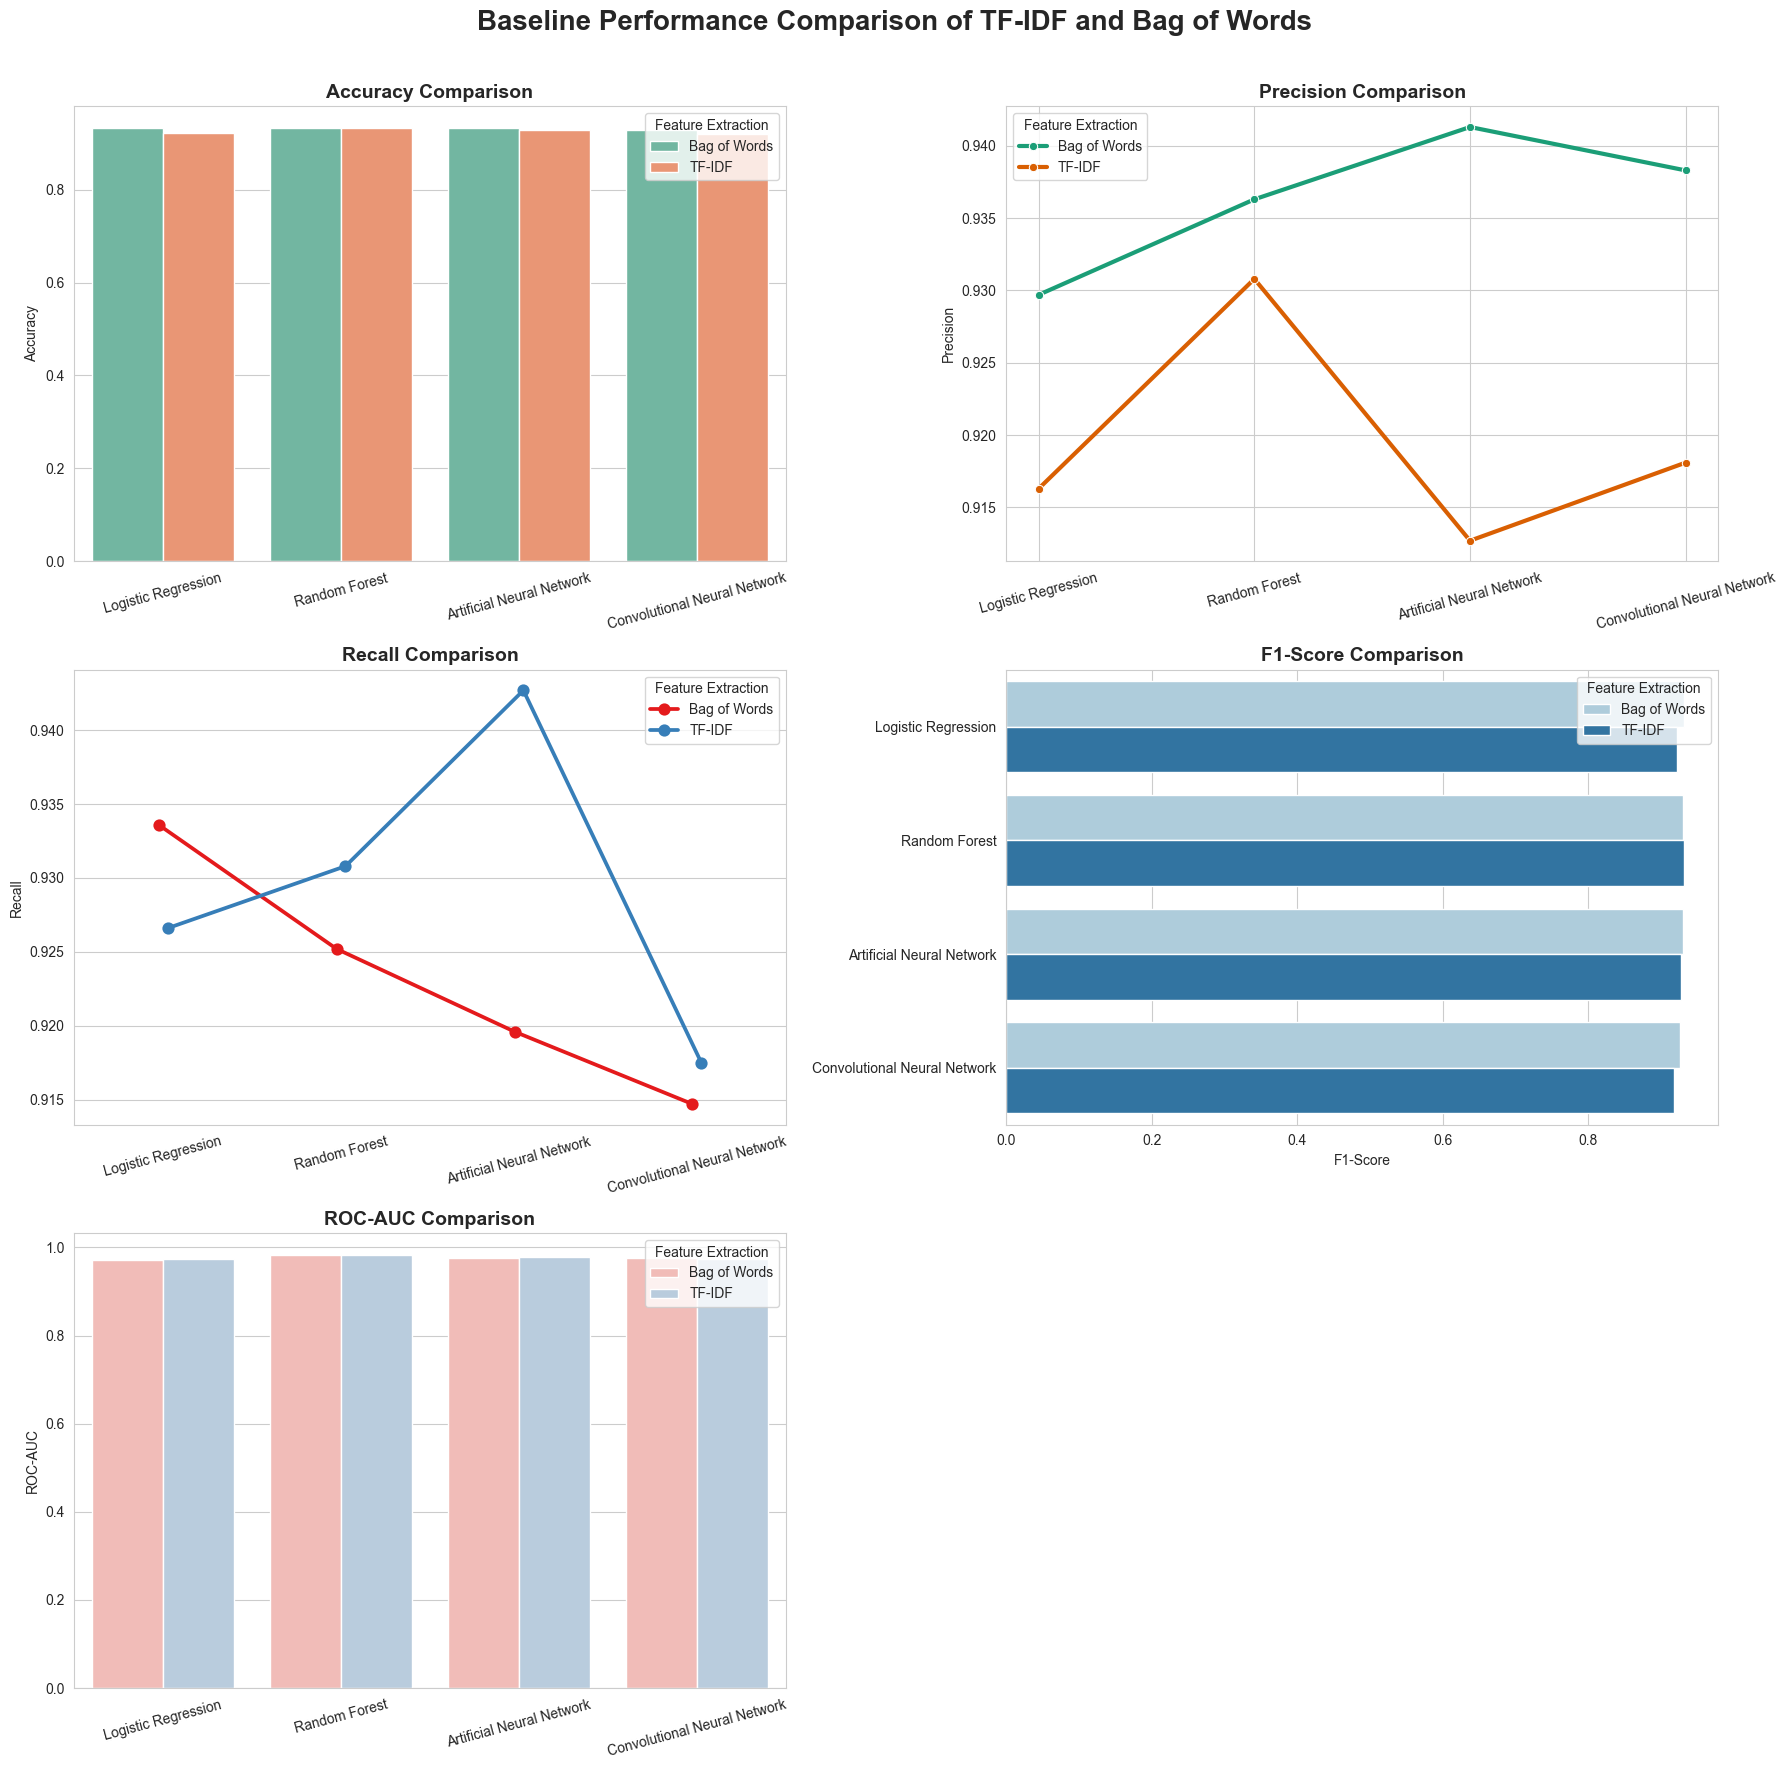

In [23]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# I applied a professional plotting style.
sns.set_style("whitegrid")

# I created a figure containing five different comparison graphs.
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# Accuracy - Grouped Bar Chart
sns.barplot(
    data=baseline_results,
    x="Baseline Model",
    y="Accuracy",
    hue="Feature Extraction",
    palette="Set2",
    ax=axes[0,0]
)
axes[0,0].set_title("Accuracy Comparison", fontsize=14, fontweight="bold")
axes[0,0].set_xlabel("")
axes[0,0].tick_params(axis='x', rotation=15)

# Precision - Line Plot
sns.lineplot(
    data=baseline_results,
    x="Baseline Model",
    y="Precision",
    hue="Feature Extraction",
    marker="o",
    linewidth=3,
    palette="Dark2",
    ax=axes[0,1]
)
axes[0,1].set_title("Precision Comparison", fontsize=14, fontweight="bold")
axes[0,1].set_xlabel("")
axes[0,1].tick_params(axis='x', rotation=15)

# Recall - Point Plot
sns.pointplot(
    data=baseline_results,
    x="Baseline Model",
    y="Recall",
    hue="Feature Extraction",
    palette="Set1",
    dodge=True,
    ax=axes[1,0]
)
axes[1,0].set_title("Recall Comparison", fontsize=14, fontweight="bold")
axes[1,0].set_xlabel("")
axes[1,0].tick_params(axis='x', rotation=15)

# F1-Score - Horizontal Bar Chart
sns.barplot(
    data=baseline_results,
    y="Baseline Model",
    x="F1-Score",
    hue="Feature Extraction",
    palette="Paired",
    ax=axes[1,1]
)
axes[1,1].set_title("F1-Score Comparison", fontsize=14, fontweight="bold")
axes[1,1].set_ylabel("")

# ROC-AUC - Grouped Bar Chart
sns.barplot(
    data=baseline_results,
    x="Baseline Model",
    y="ROC-AUC",
    hue="Feature Extraction",
    palette="Pastel1",
    ax=axes[2,0]
)
axes[2,0].set_title("ROC-AUC Comparison", fontsize=14, fontweight="bold")
axes[2,0].set_xlabel("")
axes[2,0].tick_params(axis='x', rotation=15)

# Remove the empty subplot.
fig.delaxes(axes[2,1])

# Add an overall title.
plt.suptitle(
    "Baseline Performance Comparison of TF-IDF and Bag of Words",
    fontsize=20,
    fontweight="bold"
)

# Adjust layout.
plt.tight_layout(rect=[0,0,1,0.97])

# Display the graphs.
plt.show()

# Combined Bar Graph for Accuracy for all Models 

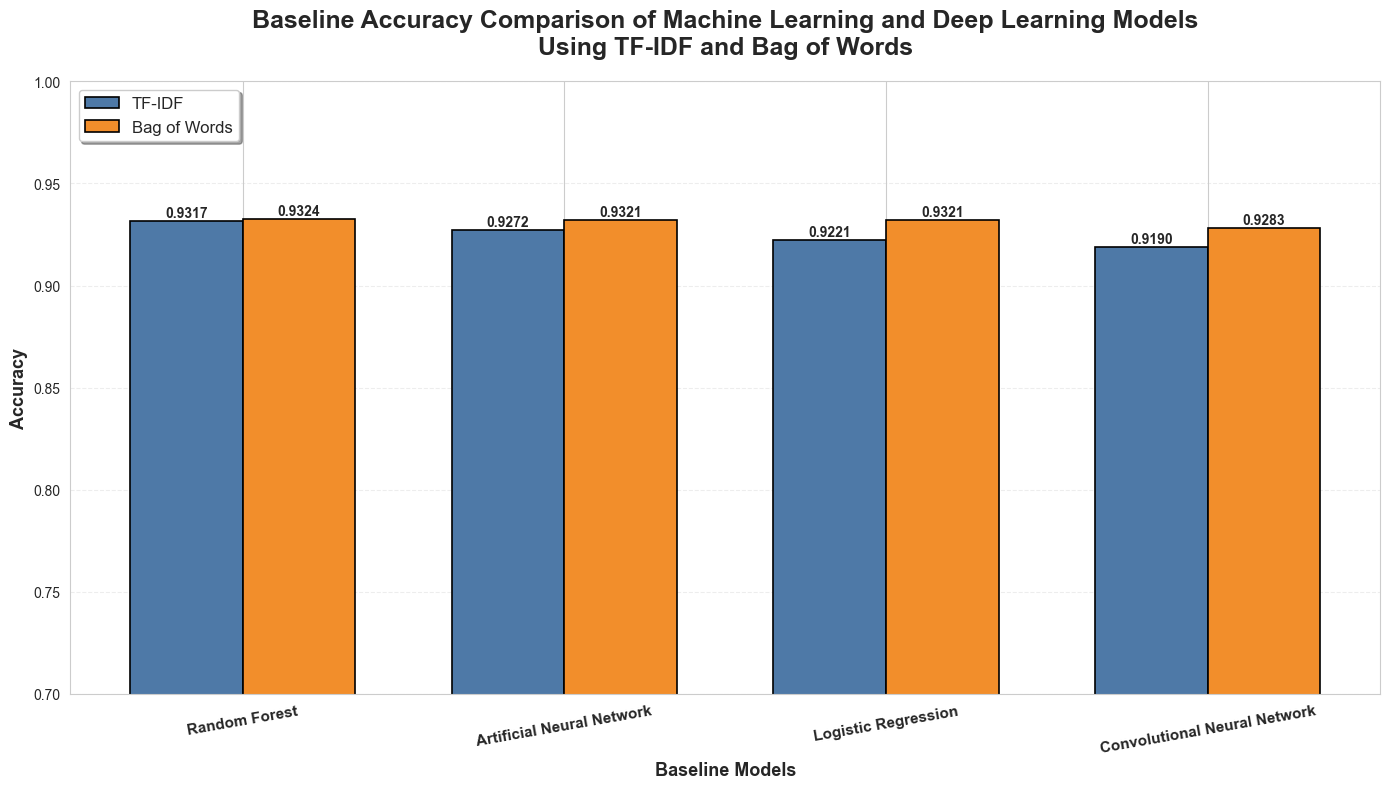

In [24]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I extracted the TF-IDF and Bag of Words results.
tfidf = baseline_results[baseline_results["Feature Extraction"] == "TF-IDF"]
bow = baseline_results[baseline_results["Feature Extraction"] == "Bag of Words"]

# I defined the model names.
models = tfidf["Baseline Model"].tolist()

# I extracted the accuracy values.
tfidf_accuracy = tfidf["Accuracy"].values
bow_accuracy = bow["Accuracy"].values

# I defined the x-axis positions.
x = np.arange(len(models))
width = 0.35

# I created the figure.
plt.figure(figsize=(14,8))

# I created the grouped bars.
bars1 = plt.bar(
    x - width/2,
    tfidf_accuracy,
    width,
    label="TF-IDF",
    color="#4E79A7",
    edgecolor="black",
    linewidth=1.2
)

bars2 = plt.bar(
    x + width/2,
    bow_accuracy,
    width,
    label="Bag of Words",
    color="#F28E2B",
    edgecolor="black",
    linewidth=1.2
)

# I added value labels above each bar.
for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# I customized the chart.
plt.xticks(
    x,
    models,
    fontsize=11,
    fontweight="bold",
    rotation=10
)

plt.ylabel(
    "Accuracy",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel(
    "Baseline Models",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "Baseline Accuracy Comparison of Machine Learning and Deep Learning Models\nUsing TF-IDF and Bag of Words",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.ylim(0.70, 1.00)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

plt.legend(
    fontsize=12,
    loc="upper left",
    frameon=True,
    shadow=True
)

plt.tight_layout()

plt.show()

# Combined Bar Graph for all Metrics for Baseline Models for both TF-IDF & BoW Techniques 

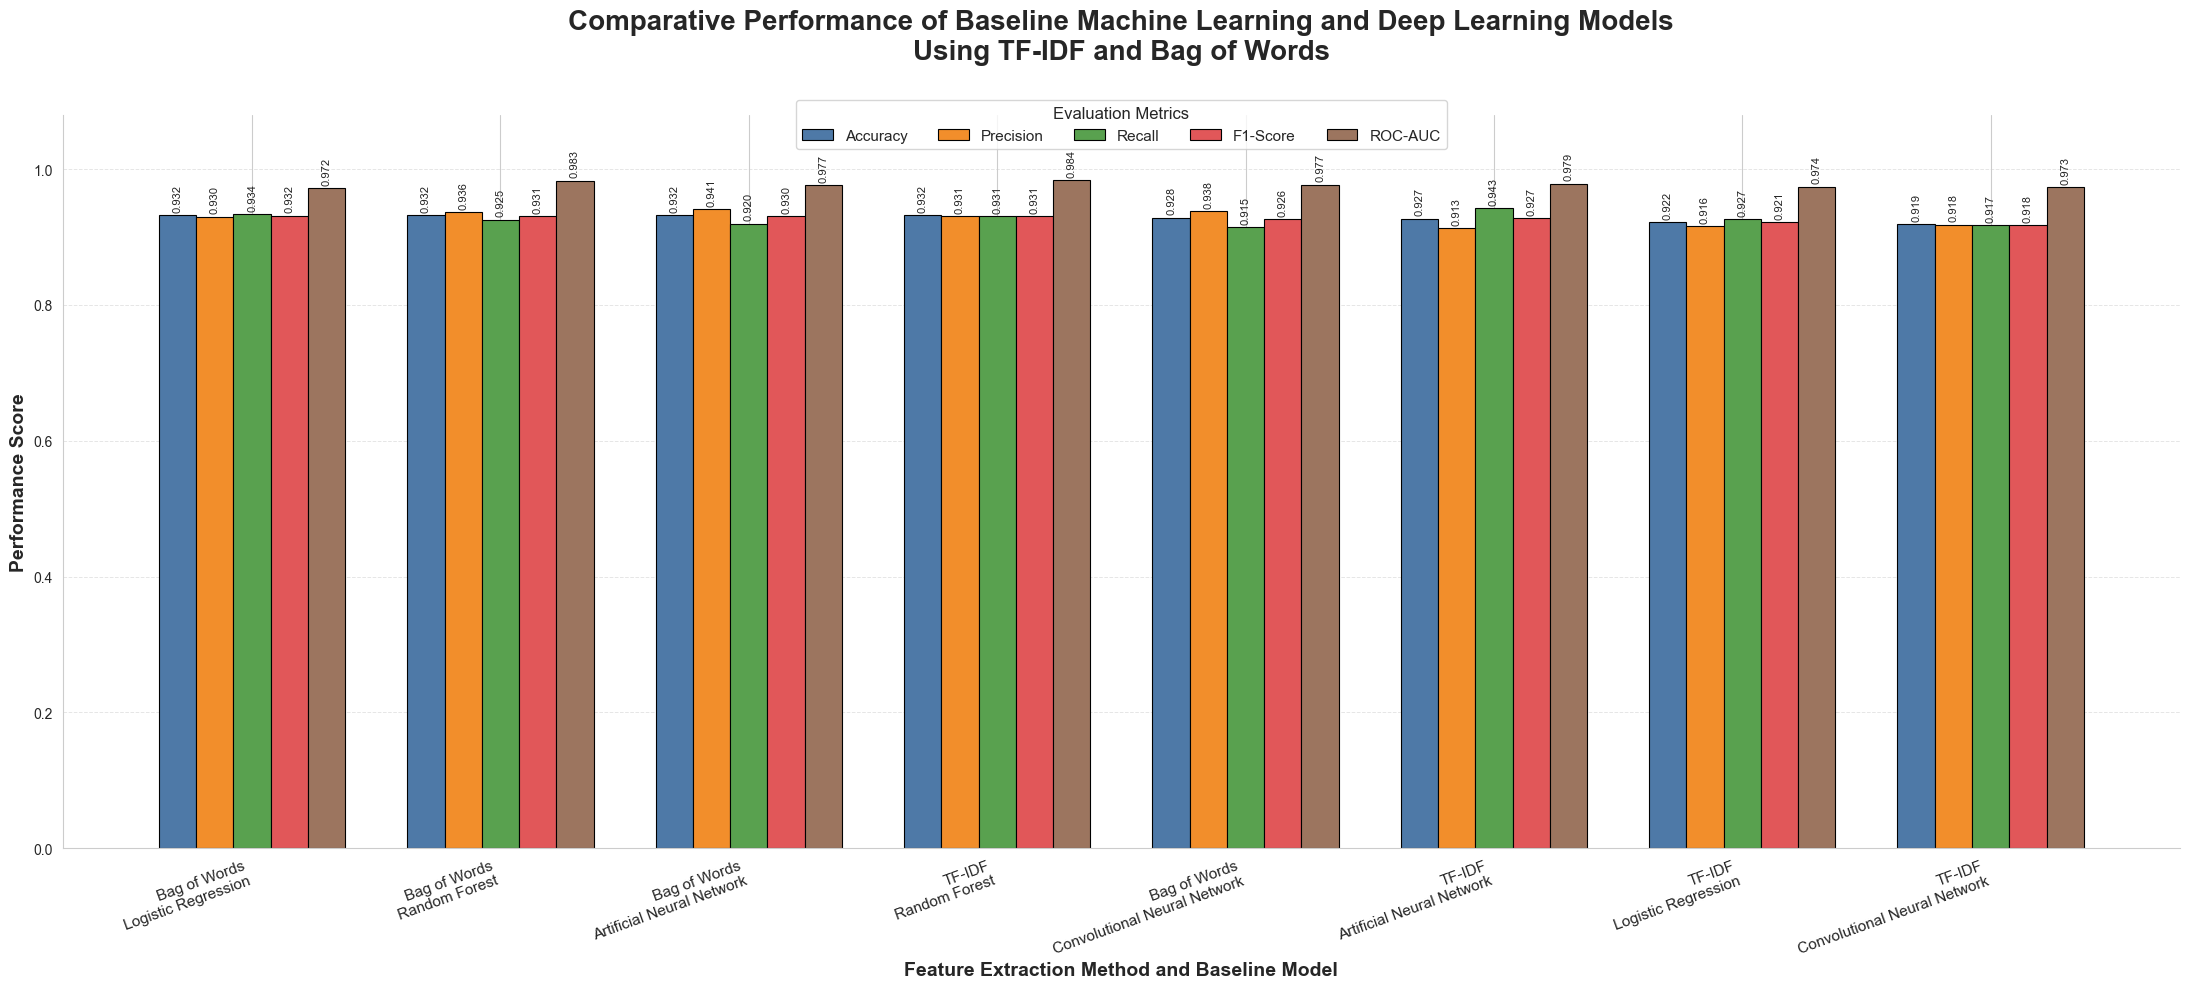

In [26]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I defined the evaluation metrics.
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

# I created labels by combining feature extraction methods and baseline models.
labels = (
    baseline_results["Feature Extraction"] + "\n" +
    baseline_results["Baseline Model"]
)

# I defined the x-axis positions.
x = np.arange(len(labels))

# I defined the width of each grouped bar.
width = 0.15

# I selected a professional colour palette.
colors = [
    "#4E79A7",   # Blue
    "#F28E2B",   # Orange
    "#59A14F",   # Green
    "#E15759",   # Red
    "#9C755F"    # Brown
]

# I created the figure.
fig, ax = plt.subplots(figsize=(22, 10))

# I plotted all evaluation metrics.
for i, metric in enumerate(metrics):

    bars = ax.bar(
        x + (i - 2) * width,
        baseline_results[metric],
        width=width,
        label=metric,
        color=colors[i],
        edgecolor="black",
        linewidth=0.8
    )

    # I displayed the values on top of each bar.
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.005,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

# I customised the x-axis.
ax.set_xticks(x)
ax.set_xticklabels(
    labels,
    rotation=20,
    ha="right",
    fontsize=11
)

# I customised the y-axis.
ax.set_ylabel(
    "Performance Score",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Feature Extraction Method and Baseline Model",
    fontsize=14,
    fontweight="bold"
)

# I set the graph title.
ax.set_title(
    "Comparative Performance of Baseline Machine Learning and Deep Learning Models\nUsing TF-IDF and Bag of Words",
    fontsize=20,
    fontweight="bold",
    pad=40
)

# I set the y-axis limits.
ax.set_ylim(0, 1.08)

# I added horizontal grid lines.
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.5
)

# I displayed the legend below the title.
ax.legend(
    title="Evaluation Metrics",
    title_fontsize=12,
    fontsize=11,
    ncol=5,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    frameon=True,
    fancybox=True,
    shadow=False
)

# I removed the top and right borders.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Combined AUC-ROC Curve for Both Techniques : Baseline Models 

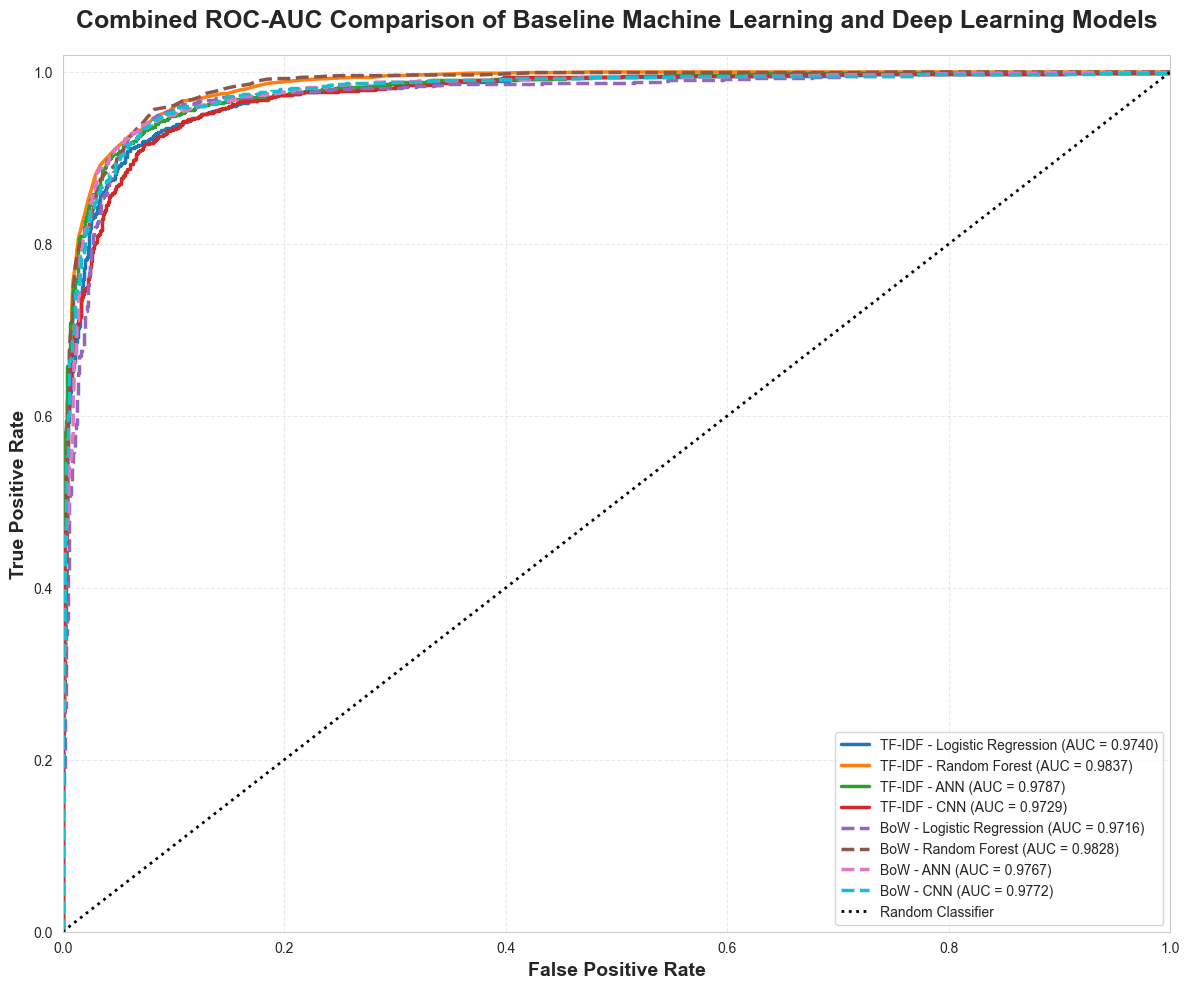

In [27]:
# I imported the required libraries.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# I created the figure.
plt.figure(figsize=(12,10))

# I defined all baseline models.
models = [

    ("TF-IDF - Logistic Regression",
     y_test,
     base_lr_tfidf_probabilities,
     "#1f77b4",
     "-"),

    ("TF-IDF - Random Forest",
     y_test,
     base_rf_tfidf_probabilities,
     "#ff7f0e",
     "-"),

    ("TF-IDF - ANN",
     y_test,
     base_ann_tfidf_probabilities,
     "#2ca02c",
     "-"),

    ("TF-IDF - CNN",
     y_test,
     base_cnn_tfidf_probabilities,
     "#d62728",
     "-"),

    ("BoW - Logistic Regression",
     y_test,
     base_lr_bow_probabilities,
     "#9467bd",
     "--"),

    ("BoW - Random Forest",
     y_test,
     base_rf_bow_probabilities,
     "#8c564b",
     "--"),

    ("BoW - ANN",
     y_test,
     base_ann_bow_probabilities,
     "#e377c2",
     "--"),

    ("BoW - CNN",
     y_test,
     base_cnn_bow_probabilities,
     "#17becf",
     "--")
]

# I plotted the ROC curve for each model.
for name, y_true, probabilities, colour, linestyle in models:

    fpr, tpr, _ = roc_curve(y_true, probabilities)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        color=colour,
        linestyle=linestyle,
        linewidth=2.5,
        label=f"{name} (AUC = {roc_auc:.4f})"
    )

# I plotted the random classifier reference line.
plt.plot(
    [0,1],
    [0,1],
    color="black",
    linestyle=":",
    linewidth=2,
    label="Random Classifier"
)

# I customised the graph.
plt.title(
    "Combined ROC-AUC Comparison of Baseline Machine Learning and Deep Learning Models",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "False Positive Rate",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=14,
    fontweight="bold"
)

plt.xlim([0,1])
plt.ylim([0,1.02])

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)

plt.tight_layout()

plt.show()

# Step 11 : Hyper Parameter Tuning 

# Model 1 : Tuned Logistic Regression (Using TF-IDF)

In [28]:
# I imported the required libraries.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the Logistic Regression model.
lr_model = LogisticRegression(
    random_state=42,
    max_iter=2000
)

# I defined the hyperparameter search space.
lr_parameter_grid = {
    "C": [0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"]
}

# I configured the Grid Search.
lr_grid_tf_idf = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_parameter_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)

# I trained the Grid Search model.
lr_grid_tf_idf.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(lr_grid_tf_idf.best_params_)

# I displayed the best cross-validation accuracy.
print("\nBest Cross-Validation Accuracy:")
print(round(lr_grid_tf_idf.best_score_, 4))

# I stored the best model.
best_lr_grid_tf_idf = lr_grid_tf_idf.best_estimator_

# I generated predictions using the best model.
lr_grid_tf_idf_predictions = best_lr_grid_tf_idf.predict(X_test_tfidf)

# I generated prediction probabilities.
lr_grid_tf_idf_probabilities = best_lr_grid_tf_idf.predict_proba(X_test_tfidf)[:, 1]

# I calculated the evaluation metrics.
lr_grid_tf_idf_accuracy = accuracy_score(
    y_test,
    lr_grid_tf_idf_predictions
)

lr_grid_tf_idf_precision = precision_score(
    y_test,
    lr_grid_tf_idf_predictions
)

lr_grid_tf_idf_recall = recall_score(
    y_test,
    lr_grid_tf_idf_predictions
)

lr_grid_tf_idf_f1_score = f1_score(
    y_test,
    lr_grid_tf_idf_predictions
)

lr_grid_tf_idf_roc_auc = roc_auc_score(
    y_test,
    lr_grid_tf_idf_probabilities
)

lr_grid_tf_idf_classification_report = classification_report(
    y_test,
    lr_grid_tf_idf_predictions
)

# I displayed the evaluation metrics.
print("\nAccuracy :", round(lr_grid_tf_idf_accuracy, 4))
print("Precision:", round(lr_grid_tf_idf_precision, 4))
print("Recall   :", round(lr_grid_tf_idf_recall, 4))
print("F1-Score :", round(lr_grid_tf_idf_f1_score, 4))
print("ROC-AUC  :", round(lr_grid_tf_idf_roc_auc, 4))

print("\nClassification Report:")
print(lr_grid_tf_idf_classification_report)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Hyperparameters:
{'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}

Best Cross-Validation Accuracy:
0.9353

Accuracy : 0.9338
Precision: 0.9353
Recall   : 0.9301
F1-Score : 0.9327
ROC-AUC  : 0.9804

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      1470
           1       0.94      0.93      0.93      1430

    accuracy                           0.93      2900
   macro avg       0.93      0.93      0.93      2900
weighted avg       0.93      0.93      0.93      2900



# Model 1 : Tuned Logistic Regression (Using BoW)

In [29]:
# I imported the required libraries.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the Logistic Regression model.
lr_model = LogisticRegression(
    random_state=42,
    max_iter=2000
)

# I defined the hyperparameter search space.
lr_parameter_grid = {
    "C": [0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"]
}

# I configured the Grid Search.
lr_grid_bow = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_parameter_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)

# I trained the Grid Search model.
lr_grid_bow.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(lr_grid_bow.best_params_)

# I displayed the best cross-validation accuracy.
print("\nBest Cross-Validation Accuracy:")
print(round(lr_grid_bow.best_score_, 4))

# I stored the best model.
best_lr_grid_bow = lr_grid_bow.best_estimator_

# I generated predictions using the best model.
lr_grid_bow_predictions = best_lr_grid_bow.predict(X_test_bow)

# I generated prediction probabilities.
lr_grid_bow_probabilities = best_lr_grid_bow.predict_proba(X_test_bow)[:, 1]

# I calculated the evaluation metrics.
lr_grid_bow_accuracy = accuracy_score(
    y_test,
    lr_grid_bow_predictions
)

lr_grid_bow_precision = precision_score(
    y_test,
    lr_grid_bow_predictions
)

lr_grid_bow_recall = recall_score(
    y_test,
    lr_grid_bow_predictions
)

lr_grid_bow_f1_score = f1_score(
    y_test,
    lr_grid_bow_predictions
)

lr_grid_bow_roc_auc = roc_auc_score(
    y_test,
    lr_grid_bow_probabilities
)

lr_grid_bow_classification_report = classification_report(
    y_test,
    lr_grid_bow_predictions
)

# I displayed the evaluation metrics.
print("\nAccuracy :", round(lr_grid_bow_accuracy, 4))
print("Precision:", round(lr_grid_bow_precision, 4))
print("Recall   :", round(lr_grid_bow_recall, 4))
print("F1-Score :", round(lr_grid_bow_f1_score, 4))
print("ROC-AUC  :", round(lr_grid_bow_roc_auc, 4))

print("\nClassification Report:")
print(lr_grid_bow_classification_report)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Hyperparameters:
{'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best Cross-Validation Accuracy:
0.9388

Accuracy : 0.9376
Precision: 0.9322
Recall   : 0.942
F1-Score : 0.937
ROC-AUC  : 0.9747

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      1470
           1       0.93      0.94      0.94      1430

    accuracy                           0.94      2900
   macro avg       0.94      0.94      0.94      2900
weighted avg       0.94      0.94      0.94      2900



# Model 2 : Tuned Random Forest  (Using TF-IDF)

In [31]:
# I imported the required libraries.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the Random Forest model.
rf_model = RandomForestClassifier(
    random_state=42
)

# I defined a reduced hyperparameter search space.
rf_parameter_grid = {
    "n_estimators": [100, 150],
    "max_depth": [20, None],
    "min_samples_split": [2],
    "min_samples_leaf": [1]
}

# I configured the Grid Search.
rf_grid_tf_idf = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_parameter_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)

# I trained the Grid Search model.
rf_grid_tf_idf.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(rf_grid_tf_idf.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(rf_grid_tf_idf.best_score_, 4))

# I stored the best model.
best_rf_grid_tf_idf = rf_grid_tf_idf.best_estimator_

# I generated predictions.
rf_grid_tf_idf_predictions = best_rf_grid_tf_idf.predict(X_test_tfidf)

# I generated prediction probabilities.
rf_grid_tf_idf_probabilities = best_rf_grid_tf_idf.predict_proba(X_test_tfidf)[:, 1]

# I calculated the evaluation metrics.
rf_grid_tf_idf_accuracy = accuracy_score(
    y_test,
    rf_grid_tf_idf_predictions
)

rf_grid_tf_idf_precision = precision_score(
    y_test,
    rf_grid_tf_idf_predictions
)

rf_grid_tf_idf_recall = recall_score(
    y_test,
    rf_grid_tf_idf_predictions
)

rf_grid_tf_idf_f1_score = f1_score(
    y_test,
    rf_grid_tf_idf_predictions
)

rf_grid_tf_idf_roc_auc = roc_auc_score(
    y_test,
    rf_grid_tf_idf_probabilities
)

rf_grid_tf_idf_classification_report = classification_report(
    y_test,
    rf_grid_tf_idf_predictions
)

# I displayed the evaluation metrics.
print("\nAccuracy :", round(rf_grid_tf_idf_accuracy, 4))
print("Precision:", round(rf_grid_tf_idf_precision, 4))
print("Recall   :", round(rf_grid_tf_idf_recall, 4))
print("F1-Score :", round(rf_grid_tf_idf_f1_score, 4))
print("ROC-AUC  :", round(rf_grid_tf_idf_roc_auc, 4))

print("\nClassification Report:")
print(rf_grid_tf_idf_classification_report)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Hyperparameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}

Best Cross-Validation Accuracy:
0.9351

Accuracy : 0.9321
Precision: 0.9314
Recall   : 0.9308
F1-Score : 0.9311
ROC-AUC  : 0.9838

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1470
           1       0.93      0.93      0.93      1430

    accuracy                           0.93      2900
   macro avg       0.93      0.93      0.93      2900
weighted avg       0.93      0.93      0.93      2900



# Model 2 : Tuned Random Forest (Using BoW)

In [32]:
# I imported the required libraries.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the Random Forest model.
rf_model = RandomForestClassifier(
    random_state=42
)

# I defined a reduced hyperparameter search space.
rf_parameter_grid = {
    "n_estimators": [100, 150],
    "max_depth": [20, None],
    "min_samples_split": [2],
    "min_samples_leaf": [1]
}

# I configured the Grid Search.
rf_grid_bow = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_parameter_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)

# I trained the Grid Search model.
rf_grid_bow.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(rf_grid_bow.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(rf_grid_bow.best_score_, 4))

# I stored the best model.
best_rf_grid_bow = rf_grid_bow.best_estimator_

# I generated predictions.
rf_grid_bow_predictions = best_rf_grid_bow.predict(
    X_test_bow
)

# I generated prediction probabilities.
rf_grid_bow_probabilities = best_rf_grid_bow.predict_proba(
    X_test_bow
)[:, 1]

# I calculated the evaluation metrics.
rf_grid_bow_accuracy = accuracy_score(
    y_test,
    rf_grid_bow_predictions
)

rf_grid_bow_precision = precision_score(
    y_test,
    rf_grid_bow_predictions
)

rf_grid_bow_recall = recall_score(
    y_test,
    rf_grid_bow_predictions
)

rf_grid_bow_f1_score = f1_score(
    y_test,
    rf_grid_bow_predictions
)

rf_grid_bow_roc_auc = roc_auc_score(
    y_test,
    rf_grid_bow_probabilities
)

rf_grid_bow_classification_report = classification_report(
    y_test,
    rf_grid_bow_predictions
)

# I displayed the evaluation metrics.
print("\nAccuracy :", round(rf_grid_bow_accuracy, 4))
print("Precision:", round(rf_grid_bow_precision, 4))
print("Recall   :", round(rf_grid_bow_recall, 4))
print("F1-Score :", round(rf_grid_bow_f1_score, 4))
print("ROC-AUC  :", round(rf_grid_bow_roc_auc, 4))

print("\nClassification Report:")
print(rf_grid_bow_classification_report)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Hyperparameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}

Best Cross-Validation Accuracy:
0.9373

Accuracy : 0.9359
Precision: 0.9362
Recall   : 0.9336
F1-Score : 0.9349
ROC-AUC  : 0.9833

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1470
           1       0.94      0.93      0.93      1430

    accuracy                           0.94      2900
   macro avg       0.94      0.94      0.94      2900
weighted avg       0.94      0.94      0.94      2900



# Model 3 : Tuned Artificial Neural Network (Using TF-IDF)

In [34]:
# I imported the required libraries.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined Early Stopping.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# I defined the manually tuned ANN model.
ann_grid_tf_idf = Sequential()

ann_grid_tf_idf.add(
    Dense(
        128,
        activation="relu",
        input_shape=(X_train_tfidf_ann.shape[1],)
    )
)

ann_grid_tf_idf.add(Dropout(0.30))

ann_grid_tf_idf.add(
    Dense(
        64,
        activation="relu"
    )
)

ann_grid_tf_idf.add(Dropout(0.30))

ann_grid_tf_idf.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

# I compiled the ANN model.
ann_grid_tf_idf.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# I trained the manually tuned ANN model.
ann_grid_tf_idf_history = ann_grid_tf_idf.fit(
    X_train_tfidf_ann,
    y_train_tfidf_smote,
    validation_split=0.20,
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# I generated prediction probabilities.
ann_grid_tf_idf_probabilities = ann_grid_tf_idf.predict(
    X_test_tfidf_ann
).ravel()

# I converted probabilities into class labels.
ann_grid_tf_idf_predictions = (
    ann_grid_tf_idf_probabilities >= 0.50
).astype(int)

# I calculated the evaluation metrics.
ann_grid_tf_idf_accuracy = accuracy_score(
    y_test,
    ann_grid_tf_idf_predictions
)

ann_grid_tf_idf_precision = precision_score(
    y_test,
    ann_grid_tf_idf_predictions
)

ann_grid_tf_idf_recall = recall_score(
    y_test,
    ann_grid_tf_idf_predictions
)

ann_grid_tf_idf_f1_score = f1_score(
    y_test,
    ann_grid_tf_idf_predictions
)

ann_grid_tf_idf_roc_auc = roc_auc_score(
    y_test,
    ann_grid_tf_idf_probabilities
)

ann_grid_tf_idf_classification_report = classification_report(
    y_test,
    ann_grid_tf_idf_predictions
)

# I displayed the selected hyperparameters.
print("\nSelected Hyperparameters")

print(f"Hidden Layer 1 Units : {128}")
print(f"Hidden Layer 2 Units : {64}")
print(f"Dropout Rate         : {0.30}")
print("Optimizer            : Adam")
print("Learning Rate        : 0.001 (Default)")
print(f"Batch Size           : {32}")
print(f"Epochs               : {15}")

# I displayed the evaluation metrics.
print("\nTuned ANN  Performance")

print(f"Accuracy : {ann_grid_tf_idf_accuracy:.4f}")
print(f"Precision: {ann_grid_tf_idf_precision:.4f}")
print(f"Recall   : {ann_grid_tf_idf_recall:.4f}")
print(f"F1-Score : {ann_grid_tf_idf_f1_score:.4f}")
print(f"ROC-AUC  : {ann_grid_tf_idf_roc_auc:.4f}")

print("\nClassification Report")

print(ann_grid_tf_idf_classification_report)

Epoch 1/15
294/294 [==============================] - 11s 24ms/step - loss: 0.3006 - accuracy: 0.8819 - val_loss: 0.1768 - val_accuracy: 0.9235
Epoch 2/15
294/294 [==============================] - 7s 23ms/step - loss: 0.1014 - accuracy: 0.9651 - val_loss: 0.1829 - val_accuracy: 0.9290
Epoch 3/15
294/294 [==============================] - 7s 23ms/step - loss: 0.0430 - accuracy: 0.9878 - val_loss: 0.2112 - val_accuracy: 0.9294
Epoch 4/15
91/91 [==============================] - 1s 7ms/step

Selected Hyperparameters
Hidden Layer 1 Units : 128
Hidden Layer 2 Units : 64
Dropout Rate         : 0.3
Optimizer            : Adam
Learning Rate        : 0.001 (Default)
Batch Size           : 32
Epochs               : 15

Model Performance
Accuracy : 0.9259
Precision: 0.9108
Recall   : 0.9420
F1-Score : 0.9261
ROC-AUC  : 0.9782

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      1470
           1       0.91      0.94      0

# Model 3 : Tuned Artificial Neural Network (Using BoW)

In [35]:
# I imported the required libraries.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined Early Stopping.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# I defined the manually tuned ANN model.
ann_grid_bow = Sequential()

ann_grid_bow.add(
    Dense(
        128,
        activation="relu",
        input_shape=(X_train_bow_ann.shape[1],)
    )
)

ann_grid_bow.add(Dropout(0.30))

ann_grid_bow.add(
    Dense(
        64,
        activation="relu"
    )
)

ann_grid_bow.add(Dropout(0.30))

ann_grid_bow.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

# I compiled the ANN model.
ann_grid_bow.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# I trained the manually tuned ANN model.
ann_grid_bow_history = ann_grid_bow.fit(
    X_train_bow_ann,
    y_train_bow_smote,
    validation_split=0.20,
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# I generated prediction probabilities.
ann_grid_bow_probabilities = ann_grid_bow.predict(
    X_test_bow_ann
).ravel()

# I converted probabilities into class labels.
ann_grid_bow_predictions = (
    ann_grid_bow_probabilities >= 0.50
).astype(int)

# I calculated the evaluation metrics.
ann_grid_bow_accuracy = accuracy_score(
    y_test,
    ann_grid_bow_predictions
)

ann_grid_bow_precision = precision_score(
    y_test,
    ann_grid_bow_predictions
)

ann_grid_bow_recall = recall_score(
    y_test,
    ann_grid_bow_predictions
)

ann_grid_bow_f1_score = f1_score(
    y_test,
    ann_grid_bow_predictions
)

ann_grid_bow_roc_auc = roc_auc_score(
    y_test,
    ann_grid_bow_probabilities
)

ann_grid_bow_classification_report = classification_report(
    y_test,
    ann_grid_bow_predictions
)

# I displayed the selected hyperparameters.
print("\nSelected Hyperparameters")
print(f"Hidden Layer 1 Units : {128}")
print(f"Hidden Layer 2 Units : {64}")
print(f"Dropout Rate         : {0.30}")
print("Optimizer            : Adam")
print("Learning Rate        : 0.001 (Default)")
print(f"Batch Size           : {32}")
print(f"Epochs               : {15}")

# I displayed the evaluation metrics.
print("\nModel Performance")

print(f"Accuracy : {ann_grid_bow_accuracy:.4f}")
print(f"Precision: {ann_grid_bow_precision:.4f}")
print(f"Recall   : {ann_grid_bow_recall:.4f}")
print(f"F1-Score : {ann_grid_bow_f1_score:.4f}")
print(f"ROC-AUC  : {ann_grid_bow_roc_auc:.4f}")

print("\nClassification Report")

print(ann_grid_bow_classification_report)

Epoch 1/15
294/294 [==============================] - 12s 26ms/step - loss: 0.3035 - accuracy: 0.8876 - val_loss: 0.1987 - val_accuracy: 0.9303
Epoch 2/15
294/294 [==============================] - 7s 25ms/step - loss: 0.1241 - accuracy: 0.9610 - val_loss: 0.1774 - val_accuracy: 0.9349
Epoch 3/15
294/294 [==============================] - 7s 24ms/step - loss: 0.0463 - accuracy: 0.9855 - val_loss: 0.2441 - val_accuracy: 0.9354
Epoch 4/15
294/294 [==============================] - 7s 25ms/step - loss: 0.0314 - accuracy: 0.9905 - val_loss: 0.2953 - val_accuracy: 0.9230
Epoch 5/15
91/91 [==============================] - 1s 5ms/step

Selected Hyperparameters
----------------------------------------
Hidden Layer 1 Units : 128
Hidden Layer 2 Units : 64
Dropout Rate         : 0.3
Optimizer            : Adam
Learning Rate        : 0.001 (Default)
Batch Size           : 32
Epochs               : 15

Model Performance
----------------------------------------
Accuracy : 0.9328
Precision: 0.9370
R

# Model 4 : Tuned Convolutional Neural Network (Using TF-IDF)

In [36]:
# I imported the required libraries.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I reshaped the TF-IDF data for CNN.
X_train_tfidf_cnn = X_train_tfidf_smote.toarray().reshape(
    X_train_tfidf_smote.shape[0],
    X_train_tfidf_smote.shape[1],
    1
)

X_test_tfidf_cnn = X_test_tfidf.toarray().reshape(
    X_test_tfidf.shape[0],
    X_test_tfidf.shape[1],
    1
)

# I defined Early Stopping.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# I defined the manually tuned CNN model.
cnn_grid_tf_idf = Sequential()

cnn_grid_tf_idf.add(
    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu",
        input_shape=(X_train_tfidf_cnn.shape[1], 1)
    )
)

cnn_grid_tf_idf.add(
    MaxPooling1D(
        pool_size=2
    )
)

cnn_grid_tf_idf.add(
    Dropout(0.30)
)

cnn_grid_tf_idf.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu"
    )
)

cnn_grid_tf_idf.add(
    MaxPooling1D(
        pool_size=2
    )
)

cnn_grid_tf_idf.add(
    Dropout(0.30)
)

cnn_grid_tf_idf.add(
    Flatten()
)

cnn_grid_tf_idf.add(
    Dense(
        64,
        activation="relu"
    )
)

cnn_grid_tf_idf.add(
    Dropout(0.30)
)

cnn_grid_tf_idf.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

# I compiled the CNN model.
cnn_grid_tf_idf.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# I trained the manually tuned CNN model.
cnn_grid_tf_idf_history = cnn_grid_tf_idf.fit(
    X_train_tfidf_cnn,
    y_train_tfidf_smote,
    validation_split=0.20,
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# I generated prediction probabilities.
cnn_grid_tf_idf_probabilities = cnn_grid_tf_idf.predict(
    X_test_tfidf_cnn
).ravel()

# I converted probabilities into class labels.
cnn_grid_tf_idf_predictions = (
    cnn_grid_tf_idf_probabilities >= 0.50
).astype(int)

# I calculated the evaluation metrics.
cnn_grid_tf_idf_accuracy = accuracy_score(
    y_test,
    cnn_grid_tf_idf_predictions
)

cnn_grid_tf_idf_precision = precision_score(
    y_test,
    cnn_grid_tf_idf_predictions
)

cnn_grid_tf_idf_recall = recall_score(
    y_test,
    cnn_grid_tf_idf_predictions
)

cnn_grid_tf_idf_f1_score = f1_score(
    y_test,
    cnn_grid_tf_idf_predictions
)

cnn_grid_tf_idf_roc_auc = roc_auc_score(
    y_test,
    cnn_grid_tf_idf_probabilities
)

cnn_grid_tf_idf_classification_report = classification_report(
    y_test,
    cnn_grid_tf_idf_predictions
)

# I displayed the selected hyperparameters.
print("\nSelected Hyperparameters")
print("Filters Layer 1      :", 128)
print("Filters Layer 2      :", 64)
print("Kernel Size Layer 1  :", 5)
print("Kernel Size Layer 2  :", 3)
print("Pooling Size         :", 2)
print("Dropout Rate         :", 0.30)
print("Optimizer            :", "Adam")
print("Learning Rate        :", "0.001 (Default)")
print("Batch Size           :", 32)
print("Epochs               :", 15)

# I displayed the evaluation metrics.
print("\nModel Performance")
print("Accuracy :", round(cnn_grid_tf_idf_accuracy, 4))
print("Precision:", round(cnn_grid_tf_idf_precision, 4))
print("Recall   :", round(cnn_grid_tf_idf_recall, 4))
print("F1-Score :", round(cnn_grid_tf_idf_f1_score, 4))
print("ROC-AUC  :", round(cnn_grid_tf_idf_roc_auc, 4))

print("\nClassification Report")
print(cnn_grid_tf_idf_classification_report)

Epoch 1/15
294/294 [==============================] - 281s 940ms/step - loss: 0.3468 - accuracy: 0.8395 - val_loss: 0.2597 - val_accuracy: 0.8907
Epoch 2/15
294/294 [==============================] - 260s 883ms/step - loss: 0.1857 - accuracy: 0.9246 - val_loss: 0.2119 - val_accuracy: 0.9158
Epoch 3/15
294/294 [==============================] - 237s 805ms/step - loss: 0.1149 - accuracy: 0.9549 - val_loss: 0.2276 - val_accuracy: 0.9205
Epoch 4/15
294/294 [==============================] - 195s 663ms/step - loss: 0.0626 - accuracy: 0.9772 - val_loss: 0.2177 - val_accuracy: 0.9256
Epoch 5/15
91/91 [==============================] - 13s 145ms/step

Selected Hyperparameters
Filters Layer 1      : 128
Filters Layer 2      : 64
Kernel Size Layer 1  : 5
Kernel Size Layer 2  : 3
Pooling Size         : 2
Dropout Rate         : 0.3
Optimizer            : Adam
Learning Rate        : 0.001 (Default)
Batch Size           : 32
Epochs               : 15

Model Performance
Accuracy : 0.9145
Precision: 0

# Model 4 : Tuned Convolutional Neural Network (Using BoW)

In [37]:
# I imported the required libraries.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I reshaped the Bag of Words data for CNN.
X_train_bow_cnn = X_train_bow_smote.toarray().reshape(
    X_train_bow_smote.shape[0],
    X_train_bow_smote.shape[1],
    1
)

X_test_bow_cnn = X_test_bow.toarray().reshape(
    X_test_bow.shape[0],
    X_test_bow.shape[1],
    1
)

# I defined Early Stopping.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# I defined the manually tuned CNN model.
cnn_grid_bow = Sequential()

cnn_grid_bow.add(
    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu",
        input_shape=(X_train_bow_cnn.shape[1], 1)
    )
)

cnn_grid_bow.add(
    MaxPooling1D(
        pool_size=2
    )
)

cnn_grid_bow.add(
    Dropout(0.30)
)

cnn_grid_bow.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu"
    )
)

cnn_grid_bow.add(
    MaxPooling1D(
        pool_size=2
    )
)

cnn_grid_bow.add(
    Dropout(0.30)
)

cnn_grid_bow.add(
    Flatten()
)

cnn_grid_bow.add(
    Dense(
        64,
        activation="relu"
    )
)

cnn_grid_bow.add(
    Dropout(0.30)
)

cnn_grid_bow.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

# I compiled the CNN model.
cnn_grid_bow.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# I trained the manually tuned CNN model.
cnn_grid_bow_history = cnn_grid_bow.fit(
    X_train_bow_cnn,
    y_train_bow_smote,
    validation_split=0.20,
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# I generated prediction probabilities.
cnn_grid_bow_probabilities = cnn_grid_bow.predict(
    X_test_bow_cnn
).ravel()

# I converted probabilities into class labels.
cnn_grid_bow_predictions = (
    cnn_grid_bow_probabilities >= 0.50
).astype(int)

# I calculated the evaluation metrics.
cnn_grid_bow_accuracy = accuracy_score(
    y_test,
    cnn_grid_bow_predictions
)

cnn_grid_bow_precision = precision_score(
    y_test,
    cnn_grid_bow_predictions
)

cnn_grid_bow_recall = recall_score(
    y_test,
    cnn_grid_bow_predictions
)

cnn_grid_bow_f1_score = f1_score(
    y_test,
    cnn_grid_bow_predictions
)

cnn_grid_bow_roc_auc = roc_auc_score(
    y_test,
    cnn_grid_bow_probabilities
)

cnn_grid_bow_classification_report = classification_report(
    y_test,
    cnn_grid_bow_predictions
)

# I displayed the selected hyperparameters.
print("\nSelected Hyperparameters")
print("Filters Layer 1      :", 128)
print("Filters Layer 2      :", 64)
print("Kernel Size Layer 1  :", 5)
print("Kernel Size Layer 2  :", 3)
print("Pooling Size         :", 2)
print("Dropout Rate         :", 0.30)
print("Optimizer            :", "Adam")
print("Learning Rate        :", "0.001 (Default)")
print("Batch Size           :", 32)
print("Epochs               :", 15)

# I displayed the evaluation metrics.
print("\nModel Performance")
print("Accuracy :", round(cnn_grid_bow_accuracy, 4))
print("Precision:", round(cnn_grid_bow_precision, 4))
print("Recall   :", round(cnn_grid_bow_recall, 4))
print("F1-Score :", round(cnn_grid_bow_f1_score, 4))
print("ROC-AUC  :", round(cnn_grid_bow_roc_auc, 4))

print("\nClassification Report")
print(cnn_grid_bow_classification_report)

Epoch 1/15
294/294 [==============================] - 193s 639ms/step - loss: 0.2977 - accuracy: 0.8848 - val_loss: 0.1921 - val_accuracy: 0.9273
Epoch 2/15
294/294 [==============================] - 202s 685ms/step - loss: 0.1490 - accuracy: 0.9448 - val_loss: 0.1605 - val_accuracy: 0.9349
Epoch 3/15
294/294 [==============================] - 226s 770ms/step - loss: 0.0877 - accuracy: 0.9693 - val_loss: 0.1457 - val_accuracy: 0.9426
Epoch 4/15
294/294 [==============================] - 210s 716ms/step - loss: 0.0532 - accuracy: 0.9820 - val_loss: 0.1610 - val_accuracy: 0.9392
Epoch 5/15
294/294 [==============================] - 211s 716ms/step - loss: 0.0387 - accuracy: 0.9871 - val_loss: 0.1894 - val_accuracy: 0.9435
Epoch 6/15
91/91 [==============================] - 12s 128ms/step

Selected Hyperparameters
Filters Layer 1      : 128
Filters Layer 2      : 64
Kernel Size Layer 1  : 5
Kernel Size Layer 2  : 3
Pooling Size         : 2
Dropout Rate         : 0.3
Optimizer            :

# Combined Comparative Table of all Tuned Models for Both Techniques 

In [39]:
import pandas as pd

# Create Combined Results DataFrame

tuned_results = pd.DataFrame({

    "Feature Extraction": [
        "TF-IDF",
        "TF-IDF",
        "TF-IDF",
        "TF-IDF",
        "Bag of Words",
        "Bag of Words",
        "Bag of Words",
        "Bag of Words"
    ],

    "Tuned Model": [
        "Logistic Regression",
        "Random Forest",
        "Artificial Neural Network",
        "Convolutional Neural Network",
        "Logistic Regression",
        "Random Forest",
        "Artificial Neural Network",
        "Convolutional Neural Network"
    ],

    "Accuracy": [
        lr_grid_tf_idf_accuracy,
        rf_grid_tf_idf_accuracy,
        ann_grid_tf_idf_accuracy,
        cnn_grid_tf_idf_accuracy,
        lr_grid_bow_accuracy,
        rf_grid_bow_accuracy,
        ann_grid_bow_accuracy,
        cnn_grid_bow_accuracy
    ],

    "Precision": [
        lr_grid_tf_idf_precision,
        rf_grid_tf_idf_precision,
        ann_grid_tf_idf_precision,
        cnn_grid_tf_idf_precision,
        lr_grid_bow_precision,
        rf_grid_bow_precision,
        ann_grid_bow_precision,
        cnn_grid_bow_precision
    ],

    "Recall": [
        lr_grid_tf_idf_recall,
        rf_grid_tf_idf_recall,
        ann_grid_tf_idf_recall,
        cnn_grid_tf_idf_recall,
        lr_grid_bow_recall,
        rf_grid_bow_recall,
        ann_grid_bow_recall,
        cnn_grid_bow_recall
    ],

    "F1-Score": [
        lr_grid_tf_idf_f1_score,
        rf_grid_tf_idf_f1_score,
        ann_grid_tf_idf_f1_score,
        cnn_grid_tf_idf_f1_score,
        lr_grid_bow_f1_score,
        rf_grid_bow_f1_score,
        ann_grid_bow_f1_score,
        cnn_grid_bow_f1_score
    ],

    "ROC-AUC": [
        lr_grid_tf_idf_roc_auc,
        rf_grid_tf_idf_roc_auc,
        ann_grid_tf_idf_roc_auc,
        cnn_grid_tf_idf_roc_auc,
        lr_grid_bow_roc_auc,
        rf_grid_bow_roc_auc,
        ann_grid_bow_roc_auc,
        cnn_grid_bow_roc_auc
    ]

})

# Round values

tuned_results.iloc[:, 2:] = tuned_results.iloc[:, 2:].round(4)

# Display professional styled table

styled_tuned_results = (
    tuned_results.style

    .hide(axis="index")

    .set_caption(
        "Table: Comparative Performance of Tuned Machine Learning and Deep Learning Models Using TF-IDF and Bag of Words"
    )

    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })

    .set_table_styles([

        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#163A5F"),
                ("text-align", "center"),
                ("padding", "12px")
            ]
        },

        {
            "selector": "th",
            "props": [
                ("background-color", "#163A5F"),
                ("color", "white"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px"),
                ("border", "1px solid white")
            ]
        },

        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("font-size", "13px"),
                ("padding", "8px"),
                ("border", "1px solid #DDDDDD")
            ]
        }

    ])

    .background_gradient(subset=["Accuracy"], cmap="Greens")
    .background_gradient(subset=["Precision"], cmap="Oranges")
    .background_gradient(subset=["Recall"], cmap="Purples")
    .background_gradient(subset=["F1-Score"], cmap="RdPu")
    .background_gradient(subset=["ROC-AUC"], cmap="BuGn")
)

styled_tuned_results

Feature Extraction,Tuned Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
TF-IDF,Logistic Regression,0.9338,0.9353,0.9301,0.9327,0.9804
TF-IDF,Random Forest,0.9321,0.9314,0.9308,0.9311,0.9838
TF-IDF,Artificial Neural Network,0.9259,0.9108,0.9420,0.9261,0.9782
TF-IDF,Convolutional Neural Network,0.9145,0.9258,0.8986,0.9120,0.9729
Bag of Words,Logistic Regression,0.9376,0.9322,0.9420,0.9370,0.9747
Bag of Words,Random Forest,0.9359,0.9362,0.9336,0.9349,0.9833
Bag of Words,Artificial Neural Network,0.9328,0.9370,0.9259,0.9314,0.9786
Bag of Words,Convolutional Neural Network,0.9348,0.9247,0.9448,0.9346,0.9840


# Visual Analysis for each metric for Tuned Models : Both Techniques 

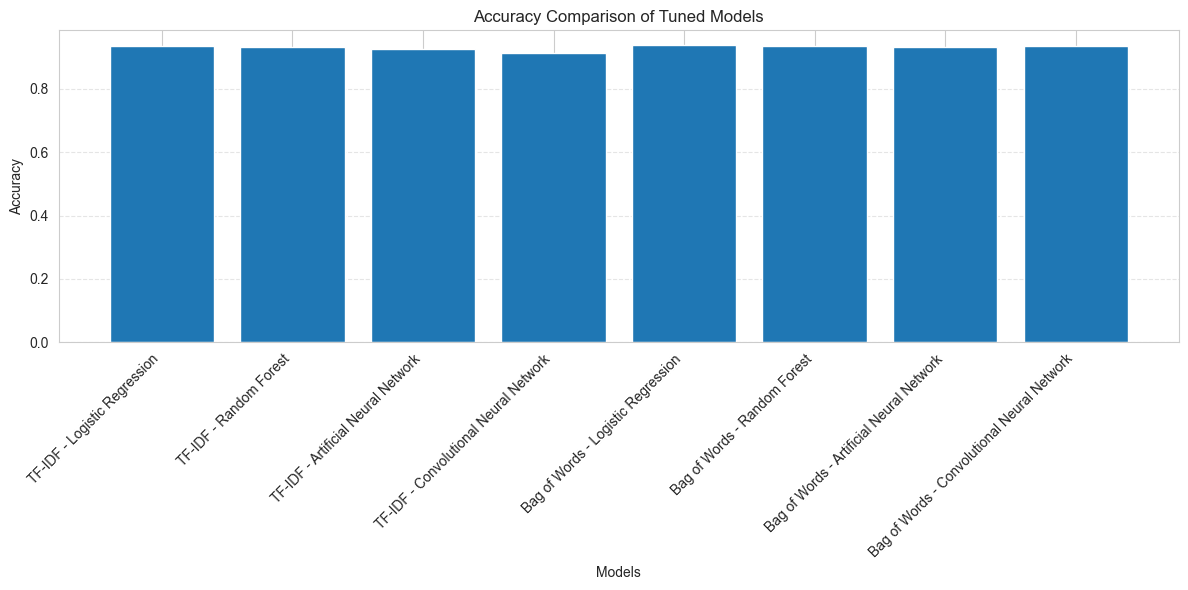

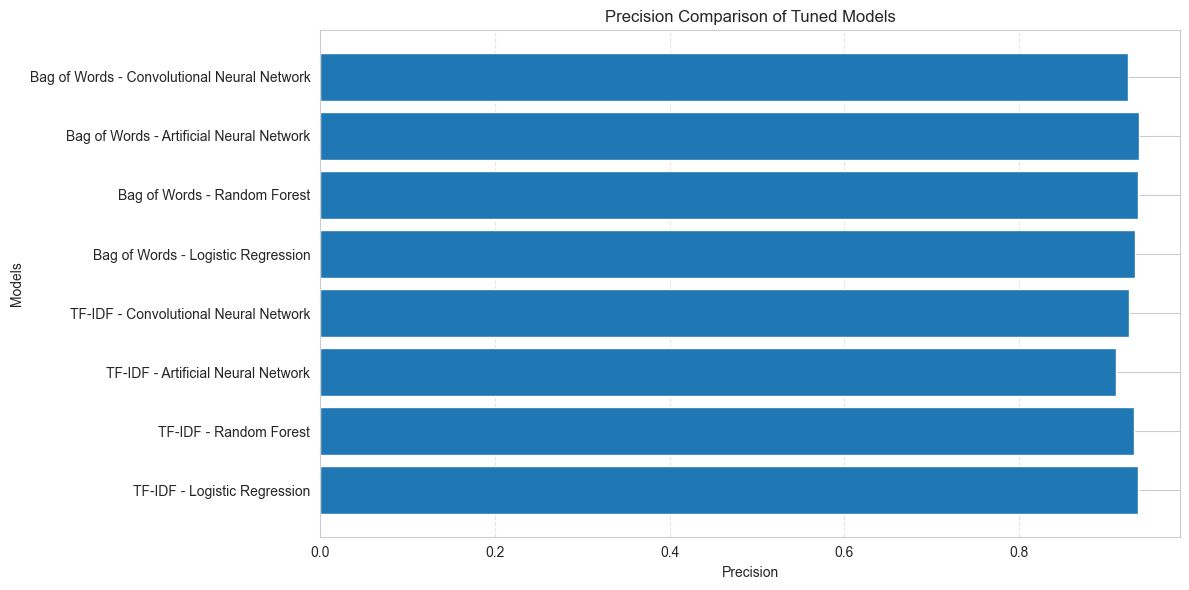

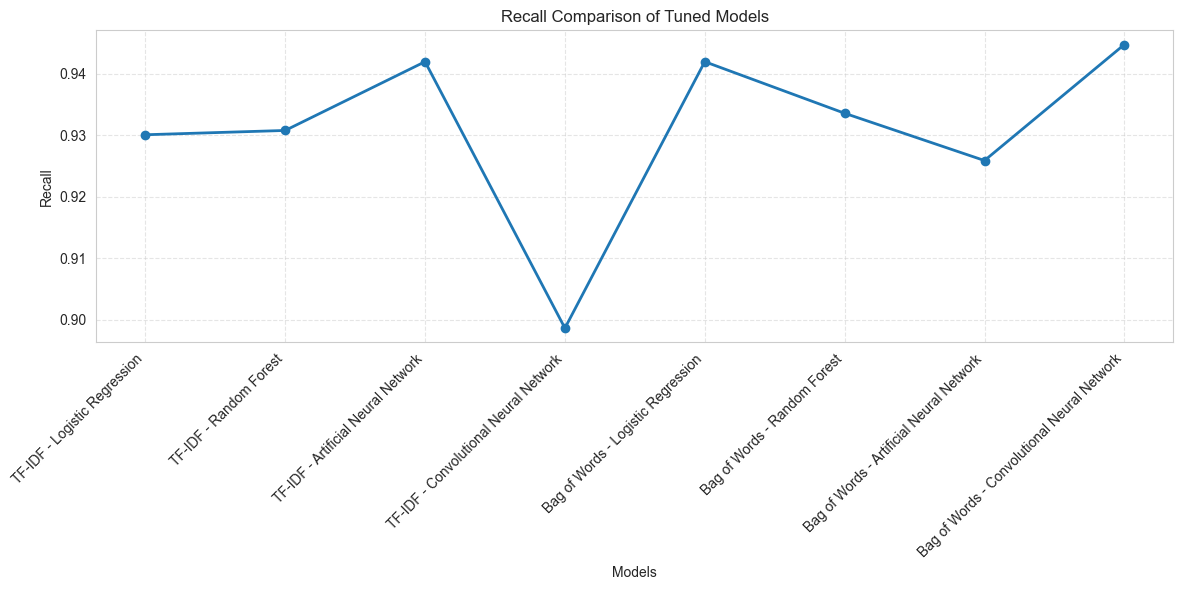

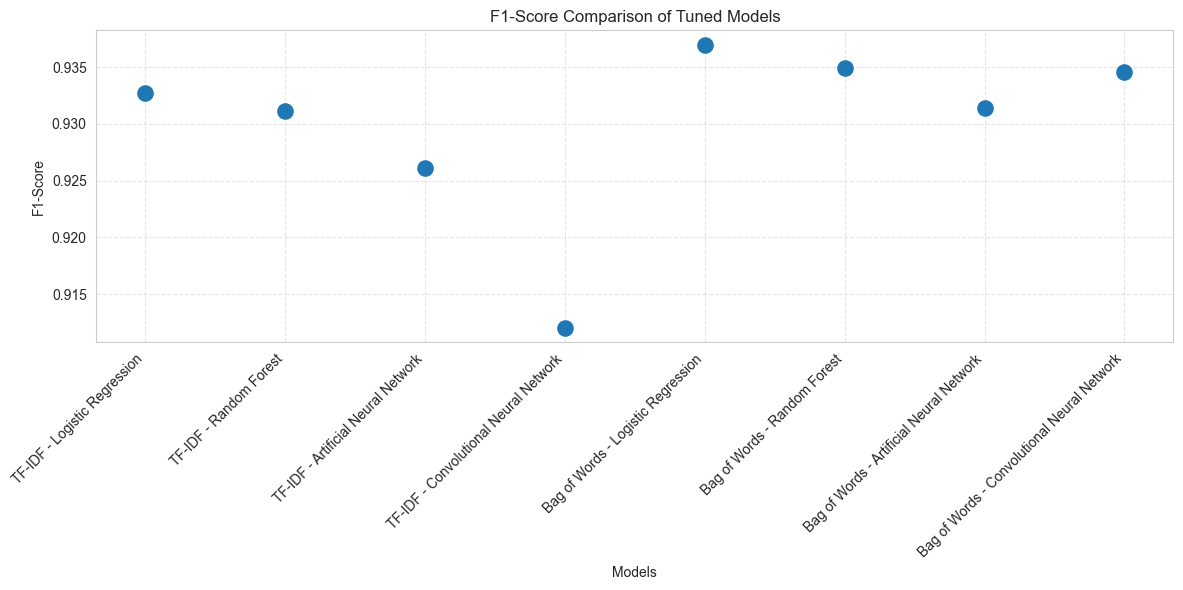

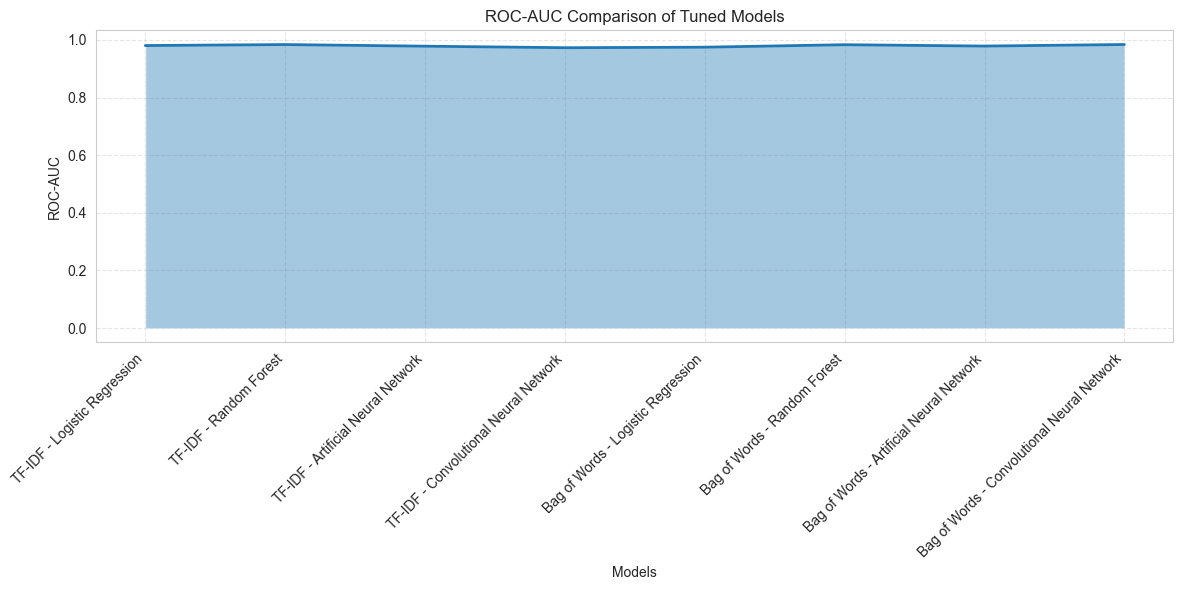

In [40]:
import matplotlib.pyplot as plt

# Create Model Labels
tuned_results["Model"] = (
    tuned_results["Feature Extraction"] +
    " - " +
    tuned_results["Tuned Model"]
)

plt.figure(figsize=(12,6))
plt.bar(tuned_results["Model"], tuned_results["Accuracy"])
plt.title("Accuracy Comparison of Tuned Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.barh(tuned_results["Model"], tuned_results["Precision"])
plt.title("Precision Comparison of Tuned Models")
plt.xlabel("Precision")
plt.ylabel("Models")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(
    tuned_results["Model"],
    tuned_results["Recall"],
    marker="o",
    linewidth=2
)
plt.title("Recall Comparison of Tuned Models")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.scatter(
    tuned_results["Model"],
    tuned_results["F1-Score"],
    s=120
)
plt.title("F1-Score Comparison of Tuned Models")
plt.xlabel("Models")
plt.ylabel("F1-Score")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.fill_between(
    tuned_results["Model"],
    tuned_results["ROC-AUC"],
    alpha=0.4
)
plt.plot(
    tuned_results["Model"],
    tuned_results["ROC-AUC"],
    linewidth=2
)
plt.title("ROC-AUC Comparison of Tuned Models")
plt.xlabel("Models")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Combined Bar Graph for all Tuned Models : Both Techniques 

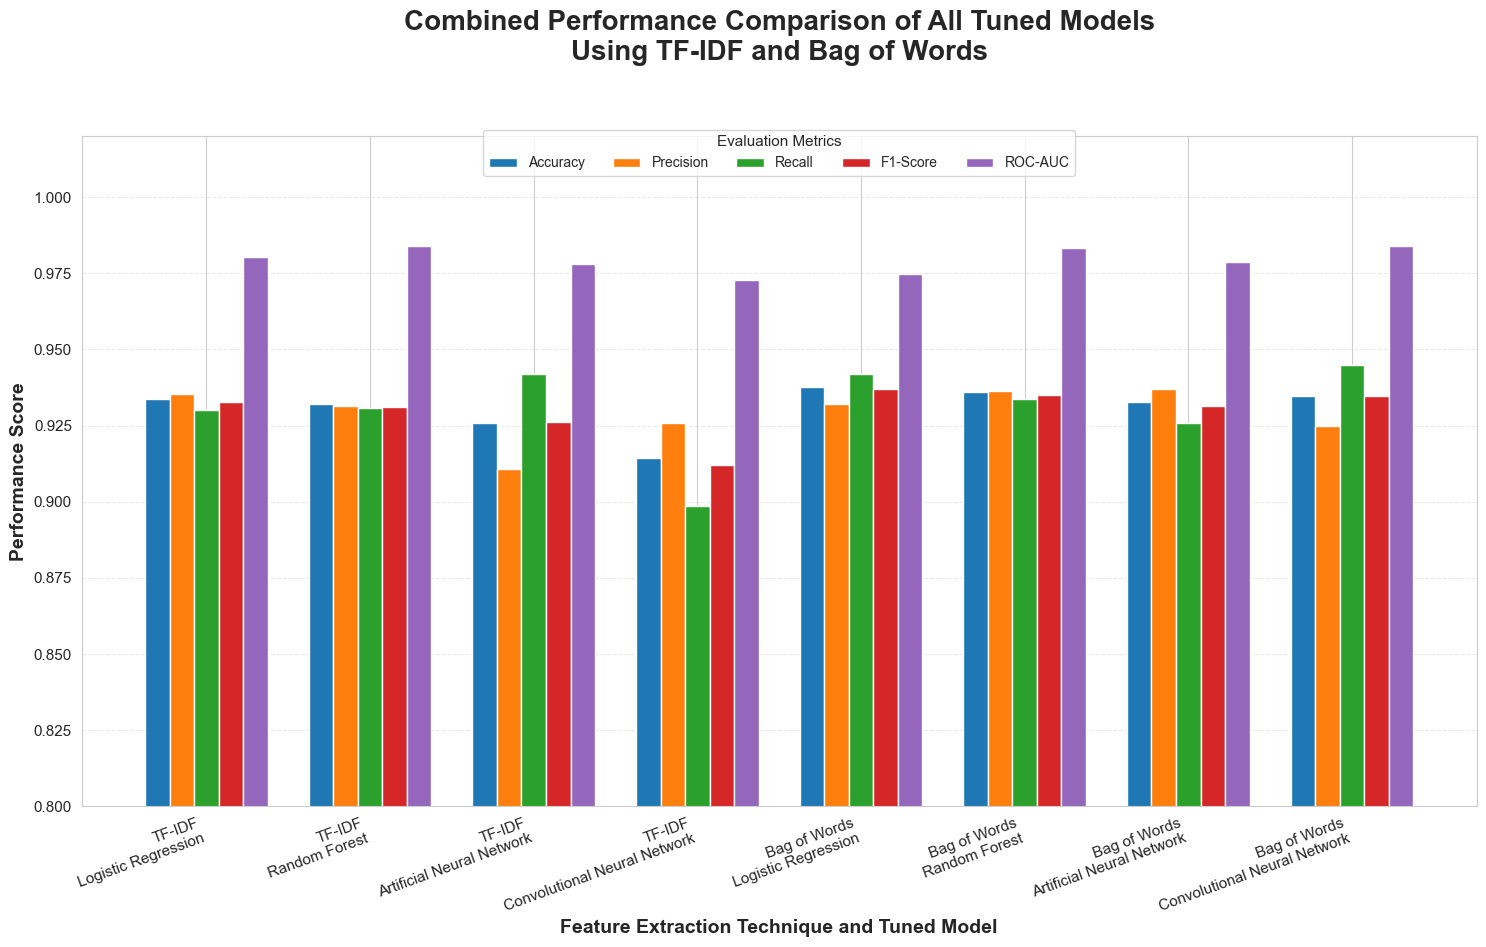

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create Combined Results DataFrame
tuned_results = pd.DataFrame({

    "Feature Extraction": [
        "TF-IDF",
        "TF-IDF",
        "TF-IDF",
        "TF-IDF",
        "Bag of Words",
        "Bag of Words",
        "Bag of Words",
        "Bag of Words"
    ],

    "Tuned Model": [
        "Logistic Regression",
        "Random Forest",
        "Artificial Neural Network",
        "Convolutional Neural Network",
        "Logistic Regression",
        "Random Forest",
        "Artificial Neural Network",
        "Convolutional Neural Network"
    ],

    "Accuracy": [
        lr_grid_tf_idf_accuracy,
        rf_grid_tf_idf_accuracy,
        ann_grid_tf_idf_accuracy,
        cnn_grid_tf_idf_accuracy,
        lr_grid_bow_accuracy,
        rf_grid_bow_accuracy,
        ann_grid_bow_accuracy,
        cnn_grid_bow_accuracy
    ],

    "Precision": [
        lr_grid_tf_idf_precision,
        rf_grid_tf_idf_precision,
        ann_grid_tf_idf_precision,
        cnn_grid_tf_idf_precision,
        lr_grid_bow_precision,
        rf_grid_bow_precision,
        ann_grid_bow_precision,
        cnn_grid_bow_precision
    ],

    "Recall": [
        lr_grid_tf_idf_recall,
        rf_grid_tf_idf_recall,
        ann_grid_tf_idf_recall,
        cnn_grid_tf_idf_recall,
        lr_grid_bow_recall,
        rf_grid_bow_recall,
        ann_grid_bow_recall,
        cnn_grid_bow_recall
    ],

    "F1-Score": [
        lr_grid_tf_idf_f1_score,
        rf_grid_tf_idf_f1_score,
        ann_grid_tf_idf_f1_score,
        cnn_grid_tf_idf_f1_score,
        lr_grid_bow_f1_score,
        rf_grid_bow_f1_score,
        ann_grid_bow_f1_score,
        cnn_grid_bow_f1_score
    ],

    "ROC-AUC": [
        lr_grid_tf_idf_roc_auc,
        rf_grid_tf_idf_roc_auc,
        ann_grid_tf_idf_roc_auc,
        cnn_grid_tf_idf_roc_auc,
        lr_grid_bow_roc_auc,
        rf_grid_bow_roc_auc,
        ann_grid_bow_roc_auc,
        cnn_grid_bow_roc_auc
    ]
})

# Create Model Labels
tuned_results["Model"] = (
    tuned_results["Feature Extraction"] +
    "\n" +
    tuned_results["Tuned Model"]
)

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

x = np.arange(len(tuned_results))
width = 0.15

plt.figure(figsize=(18,10))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i-2)*width,
        tuned_results[metric],
        width=width,
        label=metric
    )

plt.title(
    "Combined Performance Comparison of All Tuned Models\nUsing TF-IDF and Bag of Words",
    fontsize=20,
    fontweight="bold",
    pad=55
)

plt.xlabel(
    "Feature Extraction Technique and Tuned Model",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Performance Score",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    x,
    tuned_results["Model"],
    rotation=20,
    ha="right",
    fontsize=11
)

plt.yticks(fontsize=11)

plt.ylim(0.80, 1.02)

plt.grid(axis="y", linestyle="--", alpha=0.4)

# Legend BELOW the title (no overlap)
plt.legend(
    title="Evaluation Metrics",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    fontsize=10,
    title_fontsize=11,
    frameon=True
)

# Extra space at the top
plt.subplots_adjust(top=0.78)

plt.show()

# Combined AUC-RUC for all Tuned Models : Both Techniques 

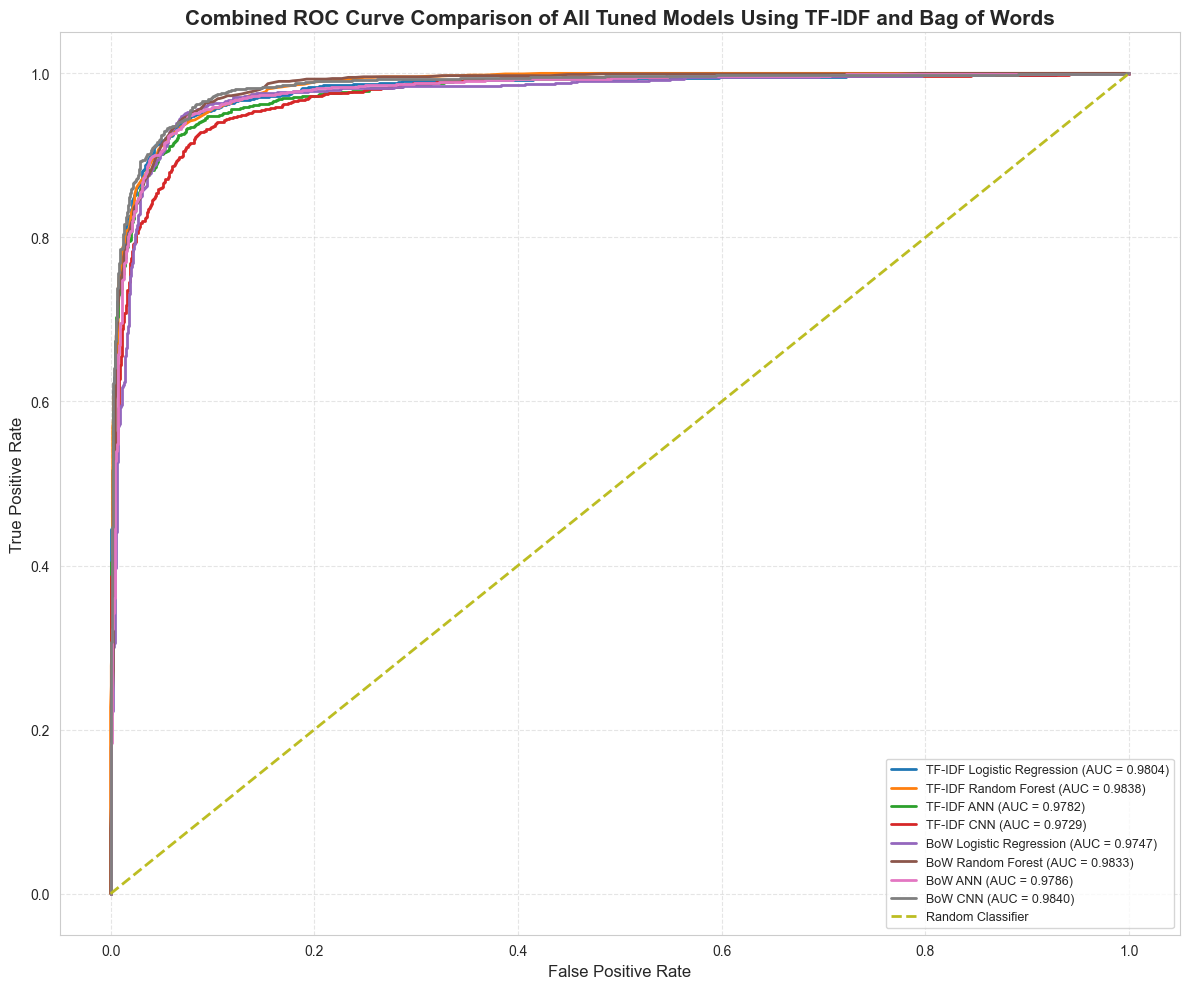

In [44]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

models = [

    ("TF-IDF Logistic Regression", lr_grid_tf_idf_probabilities),
    ("TF-IDF Random Forest", rf_grid_tf_idf_probabilities),
    ("TF-IDF ANN", ann_grid_tf_idf_probabilities),
    ("TF-IDF CNN", cnn_grid_tf_idf_probabilities),

    ("BoW Logistic Regression", lr_grid_bow_probabilities),
    ("BoW Random Forest", rf_grid_bow_probabilities),
    ("BoW ANN", ann_grid_bow_probabilities),
    ("BoW CNN", cnn_grid_bow_probabilities)

]

for model_name, probabilities in models:

    fpr, tpr, _ = roc_curve(y_test, probabilities)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title(
    "Combined ROC Curve Comparison of All Tuned Models Using TF-IDF and Bag of Words",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.legend(
    loc="lower right",
    fontsize=9
)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# Combined Comparative Table for all Baseline & Tuned Models : Both Techniques 

In [54]:
import pandas as pd

# Create copies so the original DataFrames remain unchanged
baseline = baseline_results.copy()
tuned = tuned_results.copy()

# Remove duplicate columns if they exist
baseline = baseline.loc[:, ~baseline.columns.duplicated()]
tuned = tuned.loc[:, ~tuned.columns.duplicated()]

# Rename only if the old column names exist
if "Baseline Model" in baseline.columns:
    baseline = baseline.rename(columns={"Baseline Model": "Model"})

if "Tuned Model" in tuned.columns:
    tuned = tuned.rename(columns={"Tuned Model": "Model"})

# Remove duplicate columns again after renaming
baseline = baseline.loc[:, ~baseline.columns.duplicated()]
tuned = tuned.loc[:, ~tuned.columns.duplicated()]

# Add Model Type column
baseline["Model Type"] = "Baseline"
tuned["Model Type"] = "Tuned"

# Keep only the required columns
baseline = baseline[
    [
        "Feature Extraction",
        "Model Type",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

tuned = tuned[
    [
        "Feature Extraction",
        "Model Type",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

# Combine both tables
combined_results = pd.concat(
    [baseline, tuned],
    ignore_index=True
)

# Round values
combined_results.iloc[:, 3:] = combined_results.iloc[:, 3:].round(4)

# Create styled table
styled_table = (
    combined_results.style
    .hide(axis="index")
    .set_caption(
        "Comparative Performance of Baseline and Tuned Machine Learning and Deep Learning Models Using TF-IDF and Bag of Words"
    )
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
    .set_properties(**{
        "text-align": "center",
        "font-family": "Segoe UI",
        "font-size": "13px",
        "padding": "10px",
        "border": "1px solid #D5DBDB"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "22px"),
                ("font-weight", "bold"),
                ("color", "#1F3A5F"),
                ("padding", "18px"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#2E4053"),
                ("color", "white"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("padding", "12px"),
                ("border", "2px solid white"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "#FBFCFC")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#F2F4F4")
            ]
        },
        {
            "selector": "tbody tr:hover",
            "props": [
                ("background-color", "#FEF5E7")
            ]
        }
    ])
    .background_gradient(subset=["Accuracy"], cmap="Greens")
    .background_gradient(subset=["Precision"], cmap="Blues")
    .background_gradient(subset=["Recall"], cmap="Oranges")
    .background_gradient(subset=["F1-Score"], cmap="Purples")
    .background_gradient(subset=["ROC-AUC"], cmap="RdPu")
)

styled_table

Feature Extraction,Model Type,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Bag of Words,Baseline,Logistic Regression,0.9324,0.9297,0.9336,0.9316,0.9716
Bag of Words,Baseline,Random Forest,0.9321,0.9363,0.9252,0.9307,0.9828
Bag of Words,Baseline,Artificial Neural Network,0.9321,0.9413,0.9196,0.9303,0.9767
TF-IDF,Baseline,Random Forest,0.9317,0.9308,0.9308,0.9308,0.9837
Bag of Words,Baseline,Convolutional Neural Network,0.9283,0.9383,0.9147,0.9263,0.9772
TF-IDF,Baseline,Artificial Neural Network,0.9272,0.9127,0.9427,0.9274,0.9787
TF-IDF,Baseline,Logistic Regression,0.9221,0.9163,0.9266,0.9214,0.9740
TF-IDF,Baseline,Convolutional Neural Network,0.9190,0.9181,0.9175,0.9178,0.9729
TF-IDF,Tuned,Logistic Regression,0.9338,0.9353,0.9301,0.9327,0.9804
TF-IDF,Tuned,Random Forest,0.9321,0.9314,0.9308,0.9311,0.9838


# Combined Comparative Bar Graph for all Baseline & Tuned Models : Both Techniques 

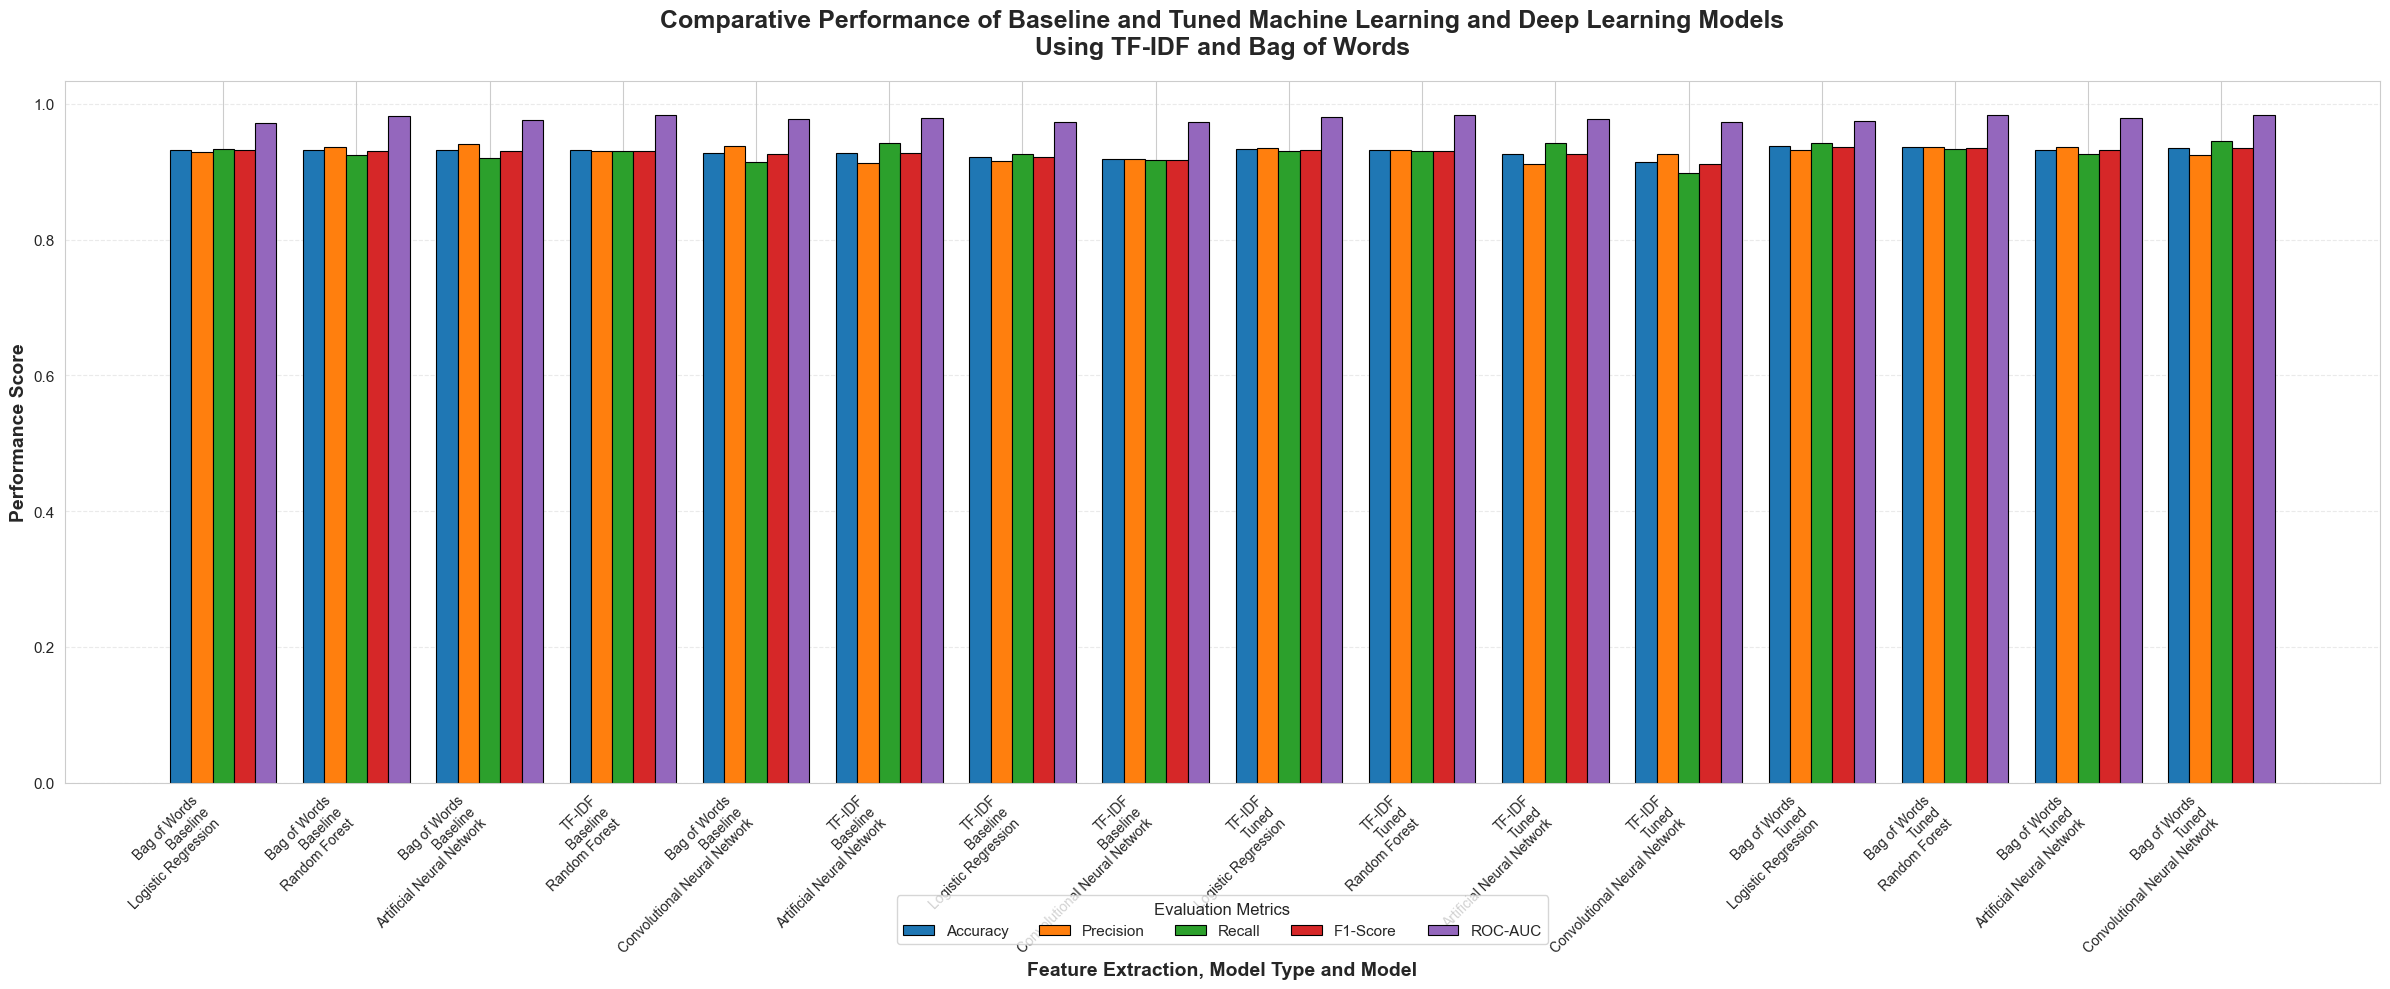

In [48]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = combined_results.copy()

plot_data["Model"] = (
    plot_data["Feature Extraction"] + "\n" +
    plot_data["Model Type"] + "\n" +
    plot_data["Model"]
)

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

x = np.arange(len(plot_data))
width = 0.16

plt.figure(figsize=(24,10))

colors = [
    "#1F77B4",   # Blue
    "#FF7F0E",   # Orange
    "#2CA02C",   # Green
    "#D62728",   # Red
    "#9467BD"    # Purple
]

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i-2)*width,
        plot_data[metric],
        width=width,
        label=metric,
        color=colors[i],
        edgecolor="black",
        linewidth=0.8
    )

plt.xticks(
    x,
    plot_data["Model"],
    rotation=45,
    ha="right",
    fontsize=10
)

plt.ylabel(
    "Performance Score",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Feature Extraction, Model Type and Model",
    fontsize=14,
    fontweight="bold"
)

plt.title(
    "Comparative Performance of Baseline and Tuned Machine Learning and Deep Learning Models\nUsing TF-IDF and Bag of Words",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.yticks(fontsize=11)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.legend(
    title="Evaluation Metrics",
    fontsize=11,
    title_fontsize=12,
    loc="upper center",
    bbox_to_anchor=(0.5,-0.15),
    ncol=5,
    frameon=True
)

plt.tight_layout()

plt.show()

# Combined Comparative AUC-ROC for all Baseline & Tuned Models : Both Techniques 

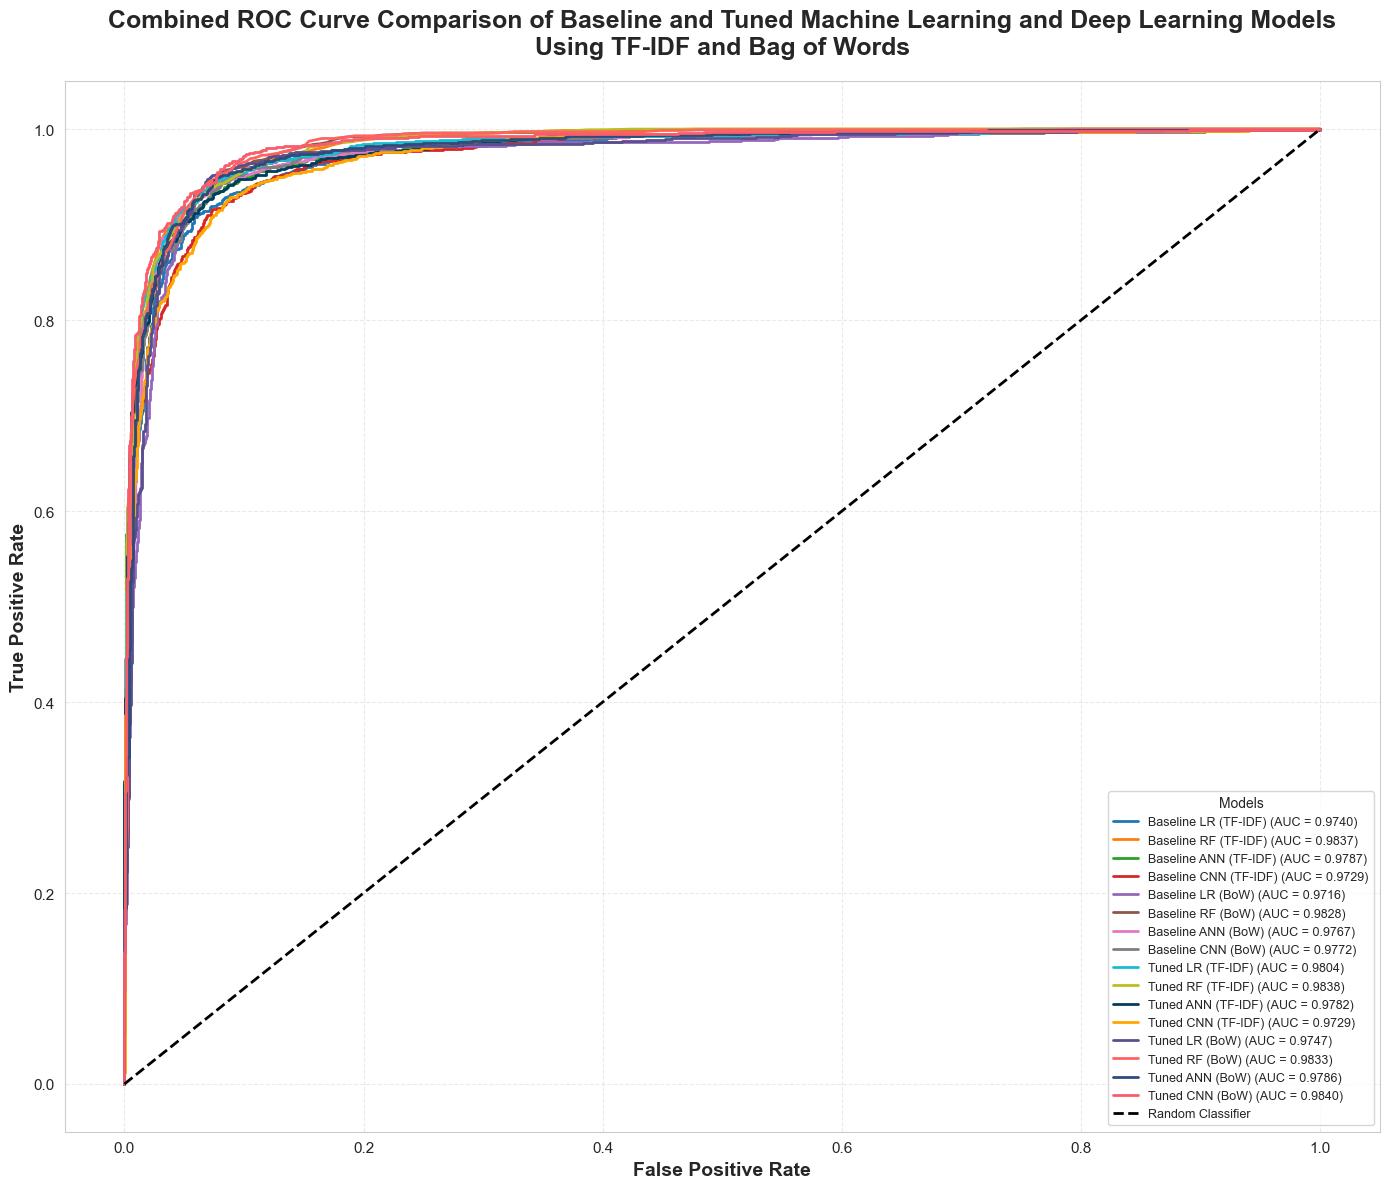

In [49]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(14,12))

roc_models = [

    ("Baseline LR (TF-IDF)", base_lr_tfidf_probabilities),
    ("Baseline RF (TF-IDF)", base_rf_tfidf_probabilities),
    ("Baseline ANN (TF-IDF)", base_ann_tfidf_probabilities),
    ("Baseline CNN (TF-IDF)", base_cnn_tfidf_probabilities),

    ("Baseline LR (BoW)", base_lr_bow_probabilities),
    ("Baseline RF (BoW)", base_rf_bow_probabilities),
    ("Baseline ANN (BoW)", base_ann_bow_probabilities),
    ("Baseline CNN (BoW)", base_cnn_bow_probabilities),

    ("Tuned LR (TF-IDF)", lr_grid_tf_idf_probabilities),
    ("Tuned RF (TF-IDF)", rf_grid_tf_idf_probabilities),
    ("Tuned ANN (TF-IDF)", ann_grid_tf_idf_probabilities),
    ("Tuned CNN (TF-IDF)", cnn_grid_tf_idf_probabilities),

    ("Tuned LR (BoW)", lr_grid_bow_probabilities),
    ("Tuned RF (BoW)", rf_grid_bow_probabilities),
    ("Tuned ANN (BoW)", ann_grid_bow_probabilities),
    ("Tuned CNN (BoW)", cnn_grid_bow_probabilities)

]

colors = [

    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",

    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",

    "#17becf",
    "#bcbd22",
    "#003f5c",
    "#ffa600",

    "#58508d",
    "#ff6361",
    "#2f4b7c",
    "#f95d6a"

]

for (label, probabilities), color in zip(roc_models, colors):

    fpr, tpr, _ = roc_curve(y_test, probabilities)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f"{label} (AUC = {roc_auc:.4f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    linewidth=2,
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=14,
    fontweight="bold"
)

plt.title(
    "Combined ROC Curve Comparison of Baseline and Tuned Machine Learning and Deep Learning Models\nUsing TF-IDF and Bag of Words",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.legend(
    fontsize=9,
    loc="lower right",
    frameon=True,
    title="Models"
)

plt.tight_layout()

plt.show()

# Best Perfoming Model 

In [51]:
import pandas as pd

baseline = baseline_results.copy()
tuned = tuned_results.copy()

# Remove duplicate columns
baseline = baseline.loc[:, ~baseline.columns.duplicated()]
tuned = tuned.loc[:, ~tuned.columns.duplicated()]

# Rename only if necessary
if "Baseline Model" in baseline.columns:
    baseline.rename(columns={"Baseline Model": "Model"}, inplace=True)

if "Tuned Model" in tuned.columns:
    tuned.rename(columns={"Tuned Model": "Model"}, inplace=True)

# Remove duplicate columns again
baseline = baseline.loc[:, ~baseline.columns.duplicated()]
tuned = tuned.loc[:, ~tuned.columns.duplicated()]

baseline["Model Type"] = "Baseline"
tuned["Model Type"] = "Tuned"

all_models = pd.concat([baseline, tuned], ignore_index=True)

best_model = all_models.loc[all_models["F1-Score"].idxmax()]

print("Best Performing Model\n")

print(f"Feature Extraction Technique : {best_model['Feature Extraction']}")
print(f"Model Type                  : {best_model['Model Type']}")
print(f"Model                       : {best_model['Model']}")
print(f"Accuracy                    : {best_model['Accuracy']:.4f}")
print(f"Precision                   : {best_model['Precision']:.4f}")
print(f"Recall                      : {best_model['Recall']:.4f}")
print(f"F1-Score                    : {best_model['F1-Score']:.4f}")
print(f"ROC-AUC                     : {best_model['ROC-AUC']:.4f}")

print("\nReason for Selecting the Best Performing Model\n")

print(
    f"The {best_model['Model']} model using the {best_model['Feature Extraction']} "
    f"feature extraction technique achieved the highest F1-Score of "
    f"{best_model['F1-Score']:.4f}. The F1-Score was selected as the primary "
    f"evaluation metric because it provides a balanced measure of Precision "
    f"and Recall, making it particularly suitable for fake news classification. "
    f"The model also achieved an Accuracy of {best_model['Accuracy']:.4f}, "
    f"Precision of {best_model['Precision']:.4f}, Recall of "
    f"{best_model['Recall']:.4f}, and ROC-AUC of {best_model['ROC-AUC']:.4f}, "
    f"demonstrating strong and balanced predictive performance across all "
    f"evaluation metrics. Therefore, this model was selected as the final "
    f"model for the proposed fake news classification system."
)

Best Performing Model

Feature Extraction Technique : Bag of Words
Model Type                  : Tuned
Model                       : Logistic Regression
Accuracy                    : 0.9376
Precision                   : 0.9322
Recall                      : 0.9420
F1-Score                    : 0.9370
ROC-AUC                     : 0.9747

Reason for Selecting the Best Performing Model

The Logistic Regression model using the Bag of Words feature extraction technique achieved the highest F1-Score of 0.9370. The F1-Score was selected as the primary evaluation metric because it provides a balanced measure of Precision and Recall, making it particularly suitable for fake news classification. The model also achieved an Accuracy of 0.9376, Precision of 0.9322, Recall of 0.9420, and ROC-AUC of 0.9747, demonstrating strong and balanced predictive performance across all evaluation metrics. Therefore, this model was selected as the final model for the proposed fake news classification system.


# K-Fold Cross Validation  

# Model 1 : Logistic Regression (Using TF-IDF) 

In [57]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross Validation
lr_grid_tfidf_cv_scores = cross_val_score(
    estimator=best_lr_grid_tf_idf,
    X=X_train_tfidf_smote,
    y=y_train_tfidf_smote,      
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

# Store Results
lr_grid_tfidf_cv_mean = np.mean(lr_grid_tfidf_cv_scores)
lr_grid_tfidf_cv_std = np.std(lr_grid_tfidf_cv_scores)

print("Logistic Regression (TF-IDF) - 5-Fold Cross Validation\n")

for i, score in enumerate(lr_grid_tfidf_cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean Cross Validation Accuracy : {lr_grid_tfidf_cv_mean:.4f}")
print(f"Standard Deviation             : {lr_grid_tfidf_cv_std:.4f}")

Logistic Regression (TF-IDF) - 5-Fold Cross Validation

Fold 1: 0.9409
Fold 2: 0.9336
Fold 3: 0.9387
Fold 4: 0.9307
Fold 5: 0.9260

Mean Cross Validation Accuracy : 0.9340
Standard Deviation             : 0.0054


# Model 1 : Logistic Regression (Using BoW)

In [58]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross Validation
lr_grid_bow_cv_scores = cross_val_score(
    estimator=best_lr_grid_bow,
    X=X_train_bow_smote,
    y=y_train_bow_smote,      
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

# Store Results
lr_grid_bow_cv_mean = np.mean(lr_grid_bow_cv_scores)
lr_grid_bow_cv_std = np.std(lr_grid_bow_cv_scores)

print("Logistic Regression (Bag of Words) - 5-Fold Cross Validation\n")

for i, score in enumerate(lr_grid_bow_cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean Cross Validation Accuracy : {lr_grid_bow_cv_mean:.4f}")
print(f"Standard Deviation             : {lr_grid_bow_cv_std:.4f}")

Logistic Regression (Bag of Words) - 5-Fold Cross Validation

Fold 1: 0.9401
Fold 2: 0.9383
Fold 3: 0.9447
Fold 4: 0.9324
Fold 5: 0.9298

Mean Cross Validation Accuracy : 0.9371
Standard Deviation             : 0.0054


# Model 2 : Random Forest (Using TF-IDF)

In [59]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross Validation
rf_grid_tfidf_cv_scores = cross_val_score(
    estimator=best_rf_grid_tf_idf,
    X=X_train_tfidf_smote,
    y=y_train_tfidf_smote,      
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

# Store Results
rf_grid_tfidf_cv_mean = np.mean(rf_grid_tfidf_cv_scores)
rf_grid_tfidf_cv_std = np.std(rf_grid_tfidf_cv_scores)

print("Random Forest (TF-IDF) - 5-Fold Cross Validation\n")

for i, score in enumerate(rf_grid_tfidf_cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean Cross Validation Accuracy : {rf_grid_tfidf_cv_mean:.4f}")
print(f"Standard Deviation             : {rf_grid_tfidf_cv_std:.4f}")

Random Forest (TF-IDF) - 5-Fold Cross Validation

Fold 1: 0.9413
Fold 2: 0.9268
Fold 3: 0.9332
Fold 4: 0.9349
Fold 5: 0.9336

Mean Cross Validation Accuracy : 0.9340
Standard Deviation             : 0.0046


# Model 2 : Random Forest (Using BoW)

In [60]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross Validation
rf_grid_bow_cv_scores = cross_val_score(
    estimator=best_rf_grid_bow,
    X=X_train_bow_smote,
    y=y_train_bow_smote,      
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

# Store Results
rf_grid_bow_cv_mean = np.mean(rf_grid_bow_cv_scores)
rf_grid_bow_cv_std = np.std(rf_grid_bow_cv_scores)

print("Random Forest (Bag of Words) - 5-Fold Cross Validation\n")

for i, score in enumerate(rf_grid_bow_cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean Cross Validation Accuracy : {rf_grid_bow_cv_mean:.4f}")
print(f"Standard Deviation             : {rf_grid_bow_cv_std:.4f}")

Random Forest (Bag of Words) - 5-Fold Cross Validation

Fold 1: 0.9452
Fold 2: 0.9332
Fold 3: 0.9396
Fold 4: 0.9328
Fold 5: 0.9302

Mean Cross Validation Accuracy : 0.9362
Standard Deviation             : 0.0054


# SHAP Analysis Based on Best Model 

Creating SHAP Explainer...
Calculating SHAP Values...
SHAP Analysis Completed Successfully!


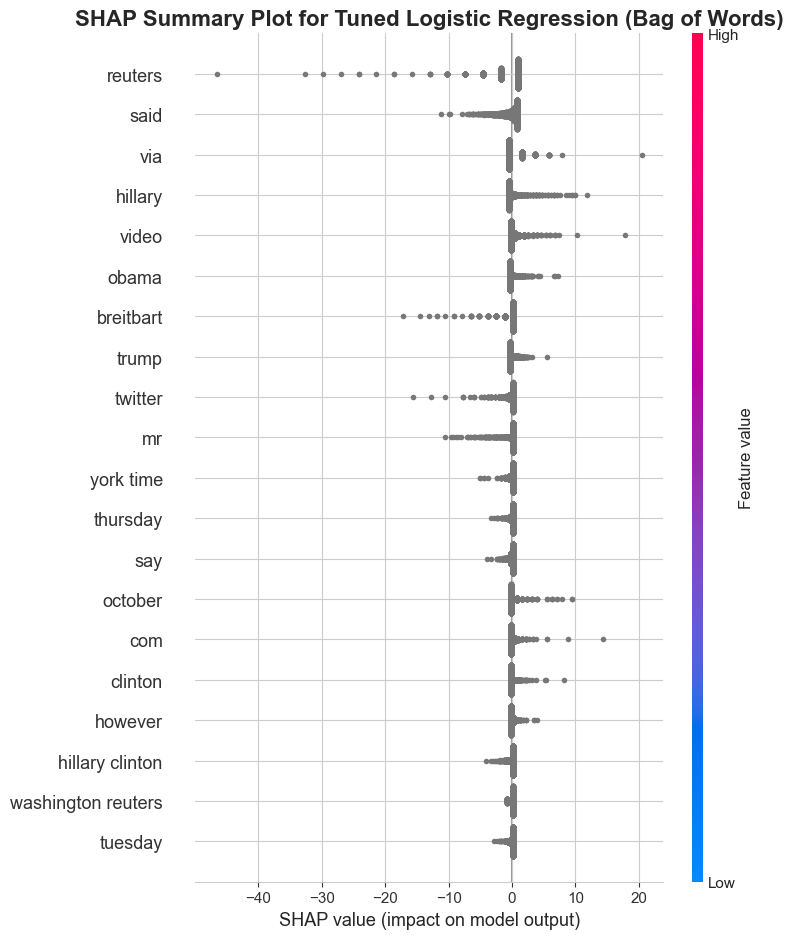

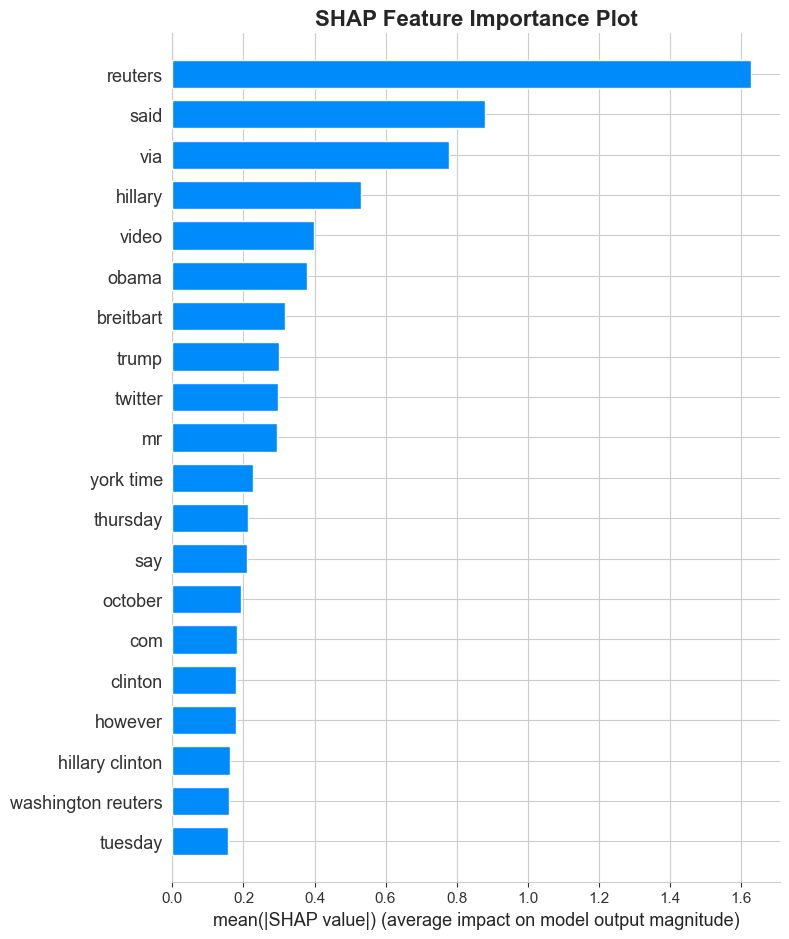

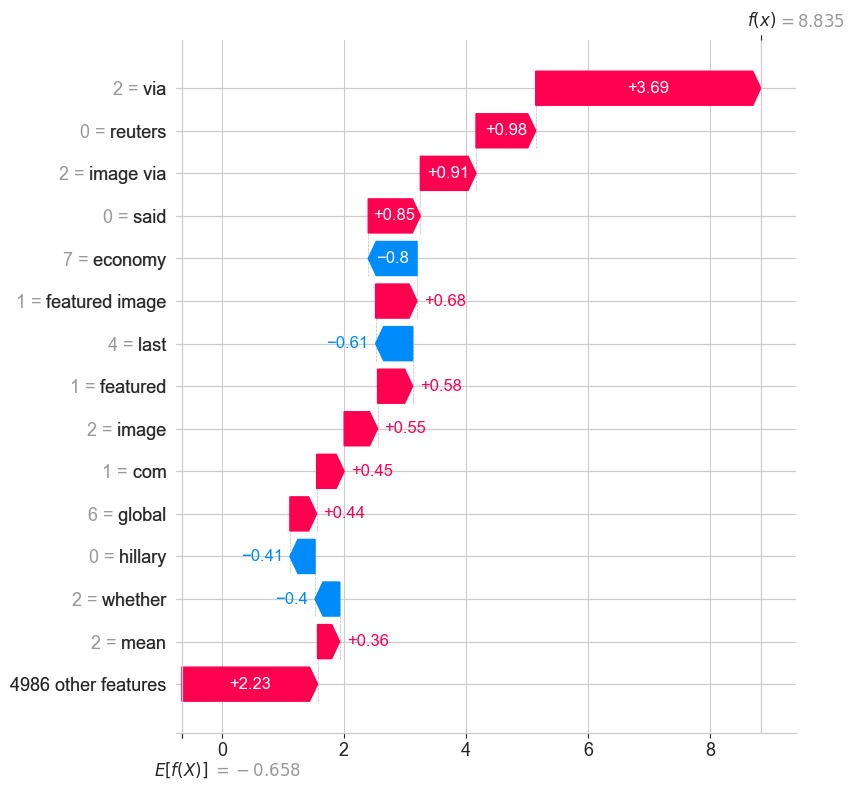

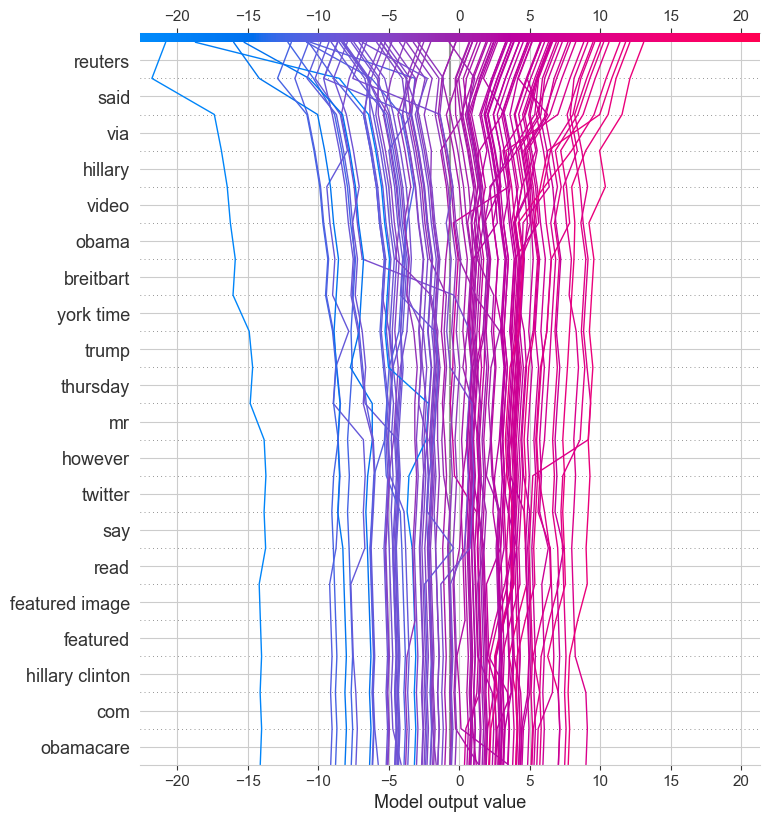

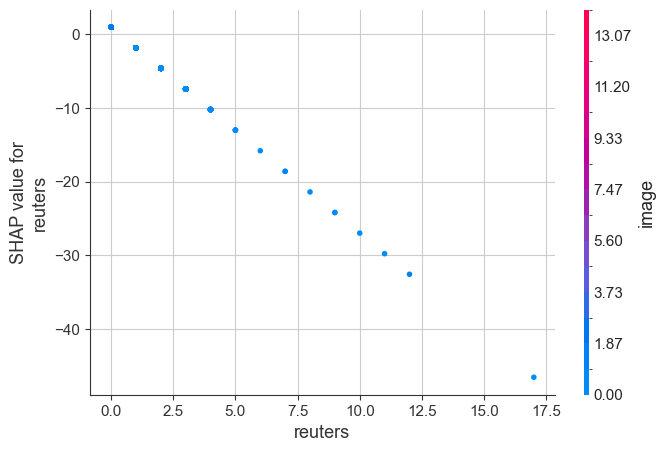

In [70]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("Creating SHAP Explainer...")

explainer = shap.Explainer(
    best_lr_grid_bow,
    X_train_bow_smote
)

print("Calculating SHAP Values...")

shap_values = explainer(X_test_bow)

print("SHAP Analysis Completed Successfully!")

plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values.values,
    X_test_bow,
    feature_names=bow_feature_names,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary Plot for Tuned Logistic Regression (Bag of Words)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values.values,
    X_test_bow,
    feature_names=bow_feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title(
    "SHAP Feature Importance Plot",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


sample_index = 0

waterfall_explanation = shap.Explanation(
    values=shap_values.values[sample_index],
    base_values=explainer.expected_value,
    data=X_test_bow[sample_index].toarray()[0],
    feature_names=bow_feature_names
)

shap.plots.waterfall(
    waterfall_explanation,
    max_display=15
)


shap.decision_plot(
    explainer.expected_value,
    shap_values.values[:100],
    feature_names=bow_feature_names
)


mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

top_feature_index = np.argmax(mean_abs_shap)

shap.dependence_plot(
    top_feature_index,
    shap_values.values,
    X_test_bow.toarray().astype(float),
    feature_names=bow_feature_names
)

# Saving the Model 

In [78]:
import joblib

# Recreate the Bag of Words vectorizer
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

# Fit on the complete cleaned dataset
bow.fit(df["clean_content"])

# Save the vectorizer
joblib.dump(bow, "bow.pkl")

# Save the best model
joblib.dump(best_lr_grid_bow, "best_lr_grid_bow.pkl")

print("Files saved successfully!")

Files saved successfully!


In [79]:
vectorizer = joblib.load("bow.pkl")

print(type(vectorizer))

<class 'sklearn.feature_extraction.text.CountVectorizer'>


# Interface Using Tkinter for Feedback Collection from Students for Human Evaluation 

In [82]:
import os
import joblib
import pandas as pd
import tkinter as tk
from tkinter import ttk, scrolledtext, messagebox

MODEL_FILE = "best_lr_grid_bow.pkl"
VECTORIZER_FILE = "bow.pkl"

try:
    model = joblib.load(MODEL_FILE)
    vectorizer = joblib.load(VECTORIZER_FILE)
except Exception as e:
    raise SystemExit(f"Error loading model/vectorizer:\n{e}")

root = tk.Tk()
root.title("Fake News Detection Prototype")
root.state("zoomed")
root.minsize(1200, 800)
root.configure(bg="#EEF4FB")

style = ttk.Style(root)
style.theme_use("clam")
style.configure("TProgressbar", thickness=18)

feedback = tk.StringVar()

def predict():
    article = txt.get("1.0", "end").strip()

    if not article:
        messagebox.showwarning("Warning", "Please enter a news article.")
        return

    try:
        X = vectorizer.transform([article])
        pred = model.predict(X)[0]
        prob = model.predict_proba(X)[0].max()*100

        if pred == 0:
            badge.config(text="FAKE NEWS", bg="#D32F2F")
        else:
            badge.config(text="REAL NEWS", bg="#2E7D32")

        confidence.config(text=f"{prob:.2f}%")
        bar["value"] = prob
        status.config(text="Prediction completed successfully.")

    except Exception as e:
        messagebox.showerror("Prediction Error", str(e))

def reset():
    txt.delete("1.0","end")
    badge.config(text="WAITING", bg="#607D8B")
    confidence.config(text="0%")
    bar["value"]=0
    feedback.set("")
    status.config(text="Ready")

def save_feedback():
    article=txt.get("1.0","end").strip()
    if not article:
        messagebox.showwarning("Warning","Enter a news article.")
        return

    df=pd.DataFrame({
        "Article":[article],
        "Prediction":[badge["text"]],
        "Confidence":[confidence["text"]],
        "Feedback":[feedback.get()]
    })

    file="Human_Evaluation_Feedback.csv"

    if os.path.exists(file):
        df.to_csv(file,mode="a",header=False,index=False)
    else:
        df.to_csv(file,index=False)

    messagebox.showinfo("Saved","Feedback saved successfully.")

header=tk.Frame(root,bg="#0D47A1",height=90)
header.pack(fill="x")

tk.Label(header,text="FAKE NEWS DETECTION PROTOTYPE",
font=("Segoe UI",24,"bold"),bg="#0D47A1",fg="white").pack(pady=(15,2))

tk.Label(header,text="Machine Learning Based News Classification",
font=("Segoe UI",11),bg="#0D47A1",fg="white").pack()

container=tk.Frame(root,bg="#EEF4FB")
container.pack(fill="both",expand=True,padx=20,pady=20)

container.grid_columnconfigure(0,weight=3)
container.grid_columnconfigure(1,weight=1)
container.grid_rowconfigure(0,weight=1)

left=tk.LabelFrame(container,text="News Article",
font=("Segoe UI",12,"bold"),bg="white")
left.grid(row=0,column=0,sticky="nsew",padx=(0,15))

txt=scrolledtext.ScrolledText(left,font=("Segoe UI",11),wrap="word")
txt.pack(fill="both",expand=True,padx=10,pady=10)

right=tk.LabelFrame(container,text="Prediction Dashboard",
font=("Segoe UI",12,"bold"),bg="white")
right.grid(row=0,column=1,sticky="nsew")

tk.Label(right,text="Prediction",font=("Segoe UI",13,"bold"),bg="white").pack(pady=(20,5))

badge=tk.Label(right,text="WAITING",font=("Segoe UI",18,"bold"),
bg="#607D8B",fg="white",width=18,pady=10)
badge.pack()

tk.Label(right,text="Confidence",font=("Segoe UI",12,"bold"),
bg="white").pack(pady=(30,5))

confidence=tk.Label(right,text="0%",font=("Segoe UI",24,"bold"),
fg="#1565C0",bg="white")
confidence.pack()

bar=ttk.Progressbar(right,maximum=100,length=250)
bar.pack(pady=10)

tk.Label(right,text="Human Evaluation",
font=("Segoe UI",12,"bold"),bg="white").pack(pady=(30,10))

ttk.Radiobutton(right,text="Prediction Correct",
variable=feedback,value="Correct").pack(anchor="w",padx=35)

ttk.Radiobutton(right,text="Prediction Incorrect",
variable=feedback,value="Incorrect").pack(anchor="w",padx=35)

buttons=tk.Frame(root,bg="#EEF4FB")
buttons.pack(fill="x",padx=20,pady=10)

for txt_btn,cmd,color in [
("Predict",predict,"#1565C0"),
("Submit Feedback",save_feedback,"#2E7D32"),
("Reset",reset,"#EF6C00"),
("Exit",root.destroy,"#C62828")]:
    tk.Button(buttons,text=txt_btn,command=cmd,bg=color,fg="white",
              font=("Segoe UI",11,"bold"),width=18,height=2).pack(side="left",padx=12)

status=tk.Label(root,text="Ready",anchor="w",bg="#CFD8DC",
font=("Segoe UI",10))
status.pack(fill="x",side="bottom")

root.mainloop()
